In [1]:
CONFIG = {
    # Paths - fixed Kaggle input
    'data_root' : '/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT',
    'image_dir' : '/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT',

    # Outputs - identical structure
    'output_dir'     : '/kaggle/working/outputs',
    'checkpoint_dir' : '/kaggle/working/checkpoints',
    'results_dir'    : '/kaggle/working/results',
    'figures_dir'    : '/kaggle/working/figures',

    # Breast Ultrasound Dataset classes
    'class_names' : ['benign', 'malignant', 'normal'],
    'num_classes' : 3,

    # Split configuration — now aligned to COVID-style: val_size only, no test_size in CONFIG
    'val_size'    : 0.15,  # 15% val, 15% test implied downstream, but split logic handles it
    # test_size not used — train/val/test = 70/15/15 stratified in code

    # Training - aligned to new values from COVID config
    'image_size'      : 224,
    'batch_size'      : 32,
    'num_epochs'      : 40,              # ← Updated from 10 to 20
    'retrain_epochs'  : 20,              # ← Updated from 5 to 10
    'lr'              : 1e-4,            # Same
    'retrain_lr'      : 5e-5,            # Same
    'weight_decay'    : 1e-4,            # Same
    'seed'            : 42,              # Same
    'num_workers'     : 4,               # Same
    'patience'        : 10,               # ← Updated from 3 to 5
    'retrain_patience': 10,               # ← Updated from 2 to 3
    'max_samples'     : None,            # Same
    'show_batch_progress': False,         # Same
    'prefetch_factor' : 2,               # Same

    # Failure analysis - copied exactly from COVID config
    'pca_components'               : 32,
    'umap_neighbors'               : 15,
    'umap_min_dist'                : 0.1,
    'k_range'                      : range(2, 7),
    'small_failure_umap_threshold' : 300,
    'max_aug_source'               : 300,
    'ece_bins'                     : 15,
    'aug_multiplier'               : 3,

    # Degradation guard - copied exactly
    'guard_f1_max_drop'       : 0.000,
    'guard_acc_max_drop'      : 0.005,
    'guard_ece_max_rise'      : 0.010,
    'guard_weak_baseline_f1'  : 0.55,
    'guard_weak_f1_max_drop'  : 0.005,
    'guard_weak_acc_max_drop' : 0.010,
    'guard_weak_ece_max_rise' : 0.025,
}

# Aligned MODELS list — now matches the subset used in the updated COVID config
MODELS = [
    # 'resnet50',
    # 'resnet101',
    # 'densenet121',
    # 'efficientnet_b3',
    # 'efficientnet_b5',
    # 'mobilenetv3_large_100',
    # 'vit_base_patch16_224',
    # 'swin_tiny_patch4_window7_224',
    'convnext_small',
    # 'maxvit_tiny_tf_224',
]

print("? CONFIG loaded - Breast Ultrasound BUSI | 3-class | val split from training")
print(f"  Classes    : {CONFIG['class_names']}")
print(f"  Training   : {CONFIG['num_epochs']} epochs | lr={CONFIG['lr']} | patience={CONFIG['patience']}")
print(f"  Retraining : {CONFIG['retrain_epochs']} epochs | lr={CONFIG['retrain_lr']} | patience={CONFIG['retrain_patience']}")
print(f"  DataLoader : workers={CONFIG['num_workers']} | persistent_workers=True | batch_progress={CONFIG['show_batch_progress']}")
print(f"  Clustering : PCA={CONFIG['pca_components']}d | K={list(CONFIG['k_range'])} | UMAP threshold={CONFIG['small_failure_umap_threshold']}")
print(f"  Guard      : weak tier if F1 < {CONFIG['guard_weak_baseline_f1']} | strict drop<={CONFIG['guard_f1_max_drop']} | weak drop<={CONFIG['guard_weak_f1_max_drop']}")
print(f"  Models     : {len(MODELS)} total")

? CONFIG loaded - Breast Ultrasound BUSI | 3-class | val split from training
  Classes    : ['benign', 'malignant', 'normal']
  Training   : 40 epochs | lr=0.0001 | patience=10
  Retraining : 20 epochs | lr=5e-05 | patience=10
  DataLoader : workers=4 | persistent_workers=True | batch_progress=False
  Clustering : PCA=32d | K=[2, 3, 4, 5, 6] | UMAP threshold=300
  Guard      : weak tier if F1 < 0.55 | strict drop<=0.0 | weak drop<=0.005
  Models     : 1 total


In [2]:
!pip install -q timm umap-learn torchmetrics

import os, random, warnings, gc, json, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
from torchvision import models
from PIL import Image

import timm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, confusion_matrix, precision_recall_fscore_support
)
import umap
import torchmetrics

try:
    from scipy import ndimage
except Exception:
    ndimage = None

try:
    from skimage.filters import threshold_otsu
except Exception:
    threshold_otsu = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

def set_all_seeds(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds for reproducible Kaggle runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_all_seeds(CONFIG['seed'])

for key in ['output_dir', 'checkpoint_dir', 'results_dir', 'figures_dir']:
    Path(CONFIG[key]).mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), "GPU is required for this Kaggle experiment."
device = torch.device("cuda")
print(f"Using device: {device} | GPU: {torch.cuda.get_device_name(0)}")
print("✓ Section 1 complete")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 88.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

2026-06-16 16:16:19.343245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781626579.564737      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781626579.622526      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781626580.149326      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781626580.149374      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781626580.149377      23 computation_placer.cc:177] computation placer alr

Using device: cuda | GPU: Tesla T4
✓ Section 1 complete


In [3]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


In [4]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)

print("GPU:", gpu_name)
print("Capability:", gpu_capability)

if gpu_capability[0] < 7:
    raise RuntimeError(
        f"{gpu_name} capability={gpu_capability} is too old for this Kaggle PyTorch CUDA build. "
        "Switch Kaggle GPU to T4/L4/A100, restart runtime, then run again."
    )

device = torch.device("cuda")


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


Using image_dir: /kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT

Total images loaded: 780

Overall class distribution:
label_name
benign       437
malignant    210
normal       133
Name: count, dtype: int64
Splits -> Train:545 | Val:118 | Test:117

Train distribution:
label_name
benign       305
malignant    147
normal        93
Name: count, dtype: int64

Val distribution:
label_name
benign       66
malignant    32
normal       20
Name: count, dtype: int64

Test distribution:
label_name
benign       66
malignant    31
normal       20
Name: count, dtype: int64

Splits saved to /kaggle/working/ and /kaggle/working/results


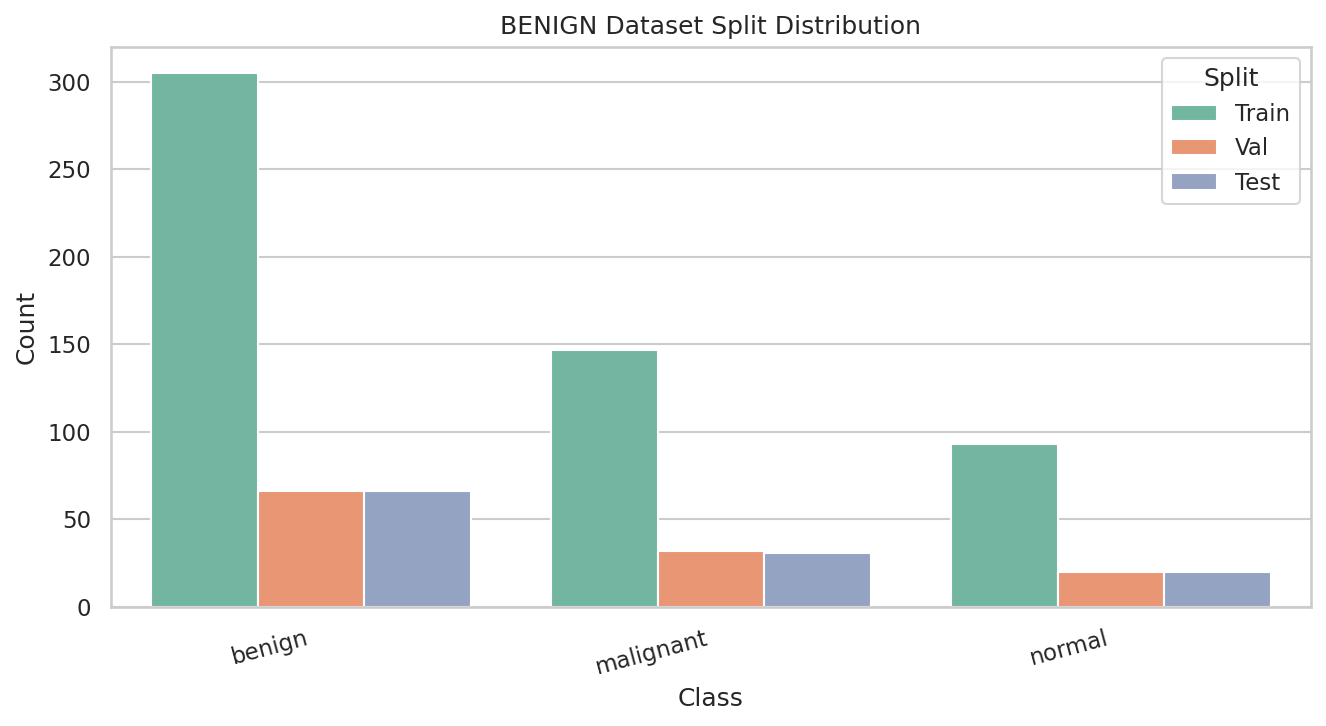

? Section 2 complete


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# =============================
# BUSI-Specific Helpers
# =============================
def is_busi_image(path: Path) -> bool:
    """Return True for BUSI image files, exclude segmentation masks."""
    if not path.is_file():
        return False
    if path.suffix.lower() not in {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}:
        return False
    return 'mask' not in path.stem.lower()


def list_busi_images(root: Path, class_name: str) -> pd.DataFrame:
    """List non-mask images from one class folder in BUSI dataset."""
    class_dir = root / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Missing class folder: {class_dir}")

    paths = sorted(p for p in class_dir.iterdir() if is_busi_image(p))
    if len(paths) == 0:
        raise FileNotFoundError(f"No valid image files found in: {class_dir}")

    return pd.DataFrame({
        'image': [p.stem for p in paths],
        'image_path': [str(p) for p in paths],
        'label_name': class_name,
        'original_labels': class_name,
    })


# =============================
# Shared Preprocessing Function
# =============================
def preprocess_labels(config: dict):
    """
    Unified preprocessing entrypoint for both BUSI and COVID-19 datasets.
    - Uses dataset-specific logic via config['class_names'] and folder layout
    - Saves train/val/test split CSVs
    - Plots and saves class distribution
    """
    image_dir = Path(config['image_dir'])

    if not image_dir.exists():
        raise FileNotFoundError(f"Data directory does not exist: {image_dir}")

    # Ensure all output directories exist
    for dir_key in ['figures_dir', 'output_dir', 'checkpoint_dir', 'results_dir']:
        Path(config[dir_key]).mkdir(parents=True, exist_ok=True)

    print(f"Using image_dir: {image_dir}")

    # Load full dataset: BUSI and COVID use different structures
    if 'covid' in str(image_dir).lower() or 'radiography' in str(image_dir).lower():
        # COVID-19: images in CLASS/images/
        def list_images(root_dir: Path, class_name: str) -> pd.DataFrame:
            class_dir = root_dir / class_name
            images_subdir = class_dir / "images"
            if not images_subdir.exists():
                raise FileNotFoundError(f"Missing 'images' subfolder: {images_subdir}")

            exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
            paths = sorted(
                p for p in images_subdir.iterdir()
                if p.is_file() and p.suffix.lower() in exts
            )
            if len(paths) == 0:
                raise FileNotFoundError(f"No images in {images_subdir}")

            return pd.DataFrame({
                'image': [p.stem for p in paths],
                'image_path': [str(p) for p in paths],
                'label_name': class_name,
                'original_labels': class_name,
            })

    else:
        # Breast Ultrasound (BUSI): images in CLASS/, filter out masks
        def list_images(root_dir: Path, class_name: str) -> pd.DataFrame:
            return list_busi_images(root_dir, class_name)

    # Load all classes
    full_df = pd.concat(
        [list_images(image_dir, class_name) for class_name in config['class_names']],
        ignore_index=True
    )

    # Map labels to indices
    label_to_idx = {name: idx for idx, name in enumerate(config['class_names'])}
    full_df['label'] = full_df['label_name'].map(label_to_idx).astype(int)
    full_df = full_df[['image', 'image_path', 'label', 'label_name', 'original_labels']].reset_index(drop=True)

    print(f"\nTotal images loaded: {len(full_df):,}")
    print("\nOverall class distribution:")
    print(full_df['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    # Stratified split: Train/Val/Test
    # Step 1: Train+Val vs Test
    test_size = 0.15 if 'benign' in config['class_names'] else 0.2  # BUSI: 15%, COVID: 20%
    train_val_df, test_df = train_test_split(
        full_df,
        test_size=test_size,
        random_state=config['seed'],
        stratify=full_df['label']
    )

    # Step 2: Train vs Val
    val_size_total = config['val_size']  # e.g., 0.15 (BUSI) or 0.10 (COVID)
    val_size_in_train = val_size_total / (1.0 - test_size)  # Scale relative to remaining
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_size_in_train,
        random_state=config['seed'],
        stratify=train_val_df['label']
    )

    # Reset indices
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print(f"Splits -> Train:{len(train_df):,} | Val:{len(val_df):,} | Test:{len(test_df):,}")

    # Print class distribution
    for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f"\n{split_name} distribution:")
        print(split_df['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    # Save splits
    splits = {'train_split.csv': train_df, 'val_split.csv': val_df, 'test_split.csv': test_df}
    for fname, df_split in splits.items():
        out_path = f"/kaggle/working/{fname}"
        df_split.to_csv(out_path, index=False)
        # Also save to results_dir for downstream consistency
        Path(config['results_dir']).mkdir(exist_ok=True)
        df_split.to_csv(f"{config['results_dir']}/{fname}", index=False)

    print(f"\nSplits saved to /kaggle/working/ and {config['results_dir']}")

    # Plot class distribution
    dist = pd.concat([
        train_df.assign(split='Train'),
        val_df.assign(split='Val'),
        test_df.assign(split='Test'),
    ])

    plt.figure(figsize=(9, 5), dpi=150)
    ax = sns.countplot(
        data=dist,
        x='label_name',
        hue='split',
        order=config['class_names'],
        palette='Set2'
    )
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    plt.xticks(rotation=15, ha='right')
    plt.legend(title='Split')
    plt.title(f"{config['class_names'][0].upper()} Dataset Split Distribution", fontsize=12)
    plt.tight_layout()

    # Save high-res plot
    plot_path = f"{config['figures_dir']}/section2_class_distribution.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

    return train_df, val_df, test_df


# ----------------------------
# Run preprocessing
# ----------------------------
train_df, val_df, test_df = preprocess_labels(CONFIG)
print("? Section 2 complete")

In [6]:
class BreastUltrasoundDataset(Dataset):
    """Breast ultrasound dataset that loads non-mask images as RGB tensors."""
    missing_warning_count = 0

    def __init__(self, df: pd.DataFrame, transform=None, image_dir=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.image_dir = image_dir

    def __len__(self):
        """Return number of samples."""
        return len(self.df)

    def __getitem__(self, idx):
        """Load image, apply transforms, and return tensor, label, and path."""
        row = self.df.iloc[idx]
        image_path = row['image_path']
        try:
            image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
            BreastUltrasoundDataset.missing_warning_count += 1
            if BreastUltrasoundDataset.missing_warning_count <= 10:
                print(f"Warning: missing image skipped via blank placeholder: {image_path}")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        except Exception as exc:
            BreastUltrasoundDataset.missing_warning_count += 1
            if BreastUltrasoundDataset.missing_warning_count <= 10:
                print(f"Warning: failed to load {image_path}: {exc}; using blank placeholder")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        if self.transform:
            image = self.transform(image)
        return image, int(row['label']), image_path


def get_transforms(split: str, image_size: int):
    """Build train/validation/test transforms for 224 RGB model inputs."""
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    if split == 'train':
        return T.Compose([
            T.RandomHorizontalFlip(0.5),
            T.RandomRotation(10),
            T.ColorJitter(brightness=0.15, contrast=0.15),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    if split == 'heavy':
        return T.Compose([
            T.RandomHorizontalFlip(0.5),
            T.RandomRotation(20),
            T.ColorJitter(brightness=0.25, contrast=0.25),
            T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    return T.Compose([
        T.Resize(image_size),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean, std),
    ])


class AugmentedBreastUltrasoundDataset(BreastUltrasoundDataset):
    """Dataset that applies heavy transforms to rows marked as augmented copies."""
    def __init__(self, df, normal_transform, heavy_transform):
        super().__init__(df, normal_transform)
        self.normal_transform = normal_transform
        self.heavy_transform = heavy_transform

    def __getitem__(self, idx):
        """Load image and choose normal or heavy transform based on is_augmented."""
        row = self.df.iloc[idx]
        transform = self.heavy_transform if bool(row.get('is_augmented', False)) else self.normal_transform
        old_transform = self.transform
        self.transform = transform
        item = super().__getitem__(idx)
        self.transform = old_transform
        return item


def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    """Compute inverse-frequency class weights for weighted cross entropy."""
    counts = df['label'].value_counts().reindex(range(num_classes)).fillna(1).astype(float).values
    total = counts.sum()
    weights = total / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


def get_dataloaders(train_df: pd.DataFrame, test_df: pd.DataFrame, config: dict, val_df: pd.DataFrame = None):
    """Create train, validation, and test loaders with weighted sampling for training."""
    if val_df is None:
        train_split, val_split = train_test_split(
            train_df, test_size=0.2, random_state=config['seed'], stratify=train_df['label']
        )
    else:
        train_split = train_df.copy()
        val_split = val_df.copy()

    train_transform = get_transforms('train', config['image_size'])
    heavy_transform = get_transforms('heavy', config['image_size'])
    eval_transform = get_transforms('test', config['image_size'])

    if 'is_augmented' in train_split.columns:
        train_ds = AugmentedBreastUltrasoundDataset(train_split, train_transform, heavy_transform)
    else:
        train_ds = BreastUltrasoundDataset(train_split, train_transform, config['image_dir'])
    val_ds = BreastUltrasoundDataset(val_split, eval_transform, config['image_dir'])
    test_ds = BreastUltrasoundDataset(test_df, eval_transform, config['image_dir'])

    class_weights = compute_class_weights(train_split, config['num_classes'])
    if 'sample_weight' in train_split.columns:
        sample_weights = train_split['sample_weight'].astype(float).values
    else:
        sample_weights = train_split['label'].map({i: class_weights[i].item() for i in range(config['num_classes'])}).values

    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    loader_kwargs = dict(
        batch_size=config['batch_size'],
        num_workers=config['num_workers'],
        pin_memory=True,
    )
    if config['num_workers'] > 0:
        loader_kwargs.update(
            persistent_workers=True,
            prefetch_factor=config.get('prefetch_factor', 2),
        )

    train_loader = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)
    return train_loader, val_loader, test_loader, class_weights


train_loader, val_loader, test_loader, class_weights = get_dataloaders(train_df, test_df, CONFIG, val_df=val_df)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")
print(f"Class weights: {class_weights.tolist()}")
print("? Section 3 complete")


Train batches: 18 | Val batches: 4 | Test batches: 4
Class weights: [0.5956284403800964, 1.2358276844024658, 1.9534050226211548]
? Section 3 complete


In [7]:
# import torch
# import torch.nn as nn
# import torchvision.models as models
# import timm


def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    """Instantiate a torchvision or timm classifier and move it to GPU."""
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet101':
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'mobilenetv3_large_100':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    else:
        # Use timm for other models (EffNet, ViT, Swin, ConvNeXt, etc.)
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    
    model = model.to(device)
    
    # Count parameters
    params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name}: {params/1e6:.2f}M params ({trainable/1e6:.2f}M trainable)")
    
    return model


def get_embedding_hook(model: nn.Module, model_name: str):
    """Register a forward hook on the penultimate layer for embedding extraction."""
    embedding_store = {}

    def hook_fn(module, inputs, output):
        out = output
        if isinstance(out, (tuple, list)):
            out = out[0]  # Handle models that output tuples (e.g., ViT returns features + attentions)
        
        if out.ndim == 4:  # CNN-style: (B, C, H, W)
            out = torch.nn.functional.adaptive_avg_pool2d(out, 1).flatten(1)
        elif out.ndim == 3:  # Transformer-style: (B, N, D)
            # Assume class token is at index 0
            out = out[:, 0] if out.shape[1] > 1 else out.mean(dim=1)
        else:
            out = out.flatten(1)
        
        embedding_store['embedding'] = out.detach().cpu()
    
    target = None

    # Architecture-specific hook targets
    if model_name.startswith('resnet'):
        target = model.avgpool
    elif model_name.startswith('densenet'):
        target = model.features
    elif model_name.startswith('efficientnet') and hasattr(model, 'global_pool'):
        target = model.global_pool
    elif model_name.startswith('mobilenetv3') and hasattr(model, 'avgpool'):
        target = model.avgpool
    elif model_name.startswith('vit') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('swin') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('convnext'):
        # ConvNeXt uses norm_pre (stem) or head.global_pool
        target = getattr(model, 'norm_pre', None) or getattr(getattr(model, 'head', None), 'global_pool', None)
    elif model_name.startswith('maxvit') and hasattr(model, 'norm'):
        target = model.norm

    if target is None:
        # Final fallback: check if model has forward_features (common in timm)
        if hasattr(model, 'forward_features'):
            raise ValueError(f"Architecture '{model_name}' supported via timm but hook target not configured. "
                           "Please add the correct penultimate layer.")
        else:
            raise ValueError(f"Unsupported model '{model_name}'. No forward_features or known hook target.")

    # Register hook
    handle = target.register_forward_hook(hook_fn)
    return handle, embedding_store


def get_model_family(model_name: str) -> str:
    """Map model name to retraining strategy group for adaptive scheduling."""
    if model_name.startswith('efficientnet'):
        return 'efficient'
    if model_name.startswith(('vit', 'swin', 'convnext', 'maxvit')):
        return 'transformer'
    return 'cnn'


print("✓ Section 4 complete")

✓ Section 4 complete


In [8]:
from torch.cuda.amp import autocast, GradScaler
from torchmetrics import classification as torchmetrics_classification
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
from pathlib import Path
import warnings

# Suppress non-critical warnings (e.g., from model loading or validation)
warnings.filterwarnings("ignore", category=UserWarning)

# ====================================
# 1. Training One Epoch (Mixed Precision)
# ====================================
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """Train one epoch using CUDA mixed precision. Returns average loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in tqdm(loader, desc='train', leave=False, disable=not CONFIG.get('show_batch_progress', False)):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


# ====================================
# 2. Evaluation: Metrics, Probabilities, Labels
# ====================================
def evaluate(model, loader, criterion, device, num_classes, class_names):
    """Evaluate model performance: loss, accuracy, F1, AUC, ECE, and outputs."""
    model.eval()
    f1_metric = torchmetrics_classification.F1Score(task='multiclass', num_classes=num_classes, average='macro').to(device)
    auc_metric = torchmetrics_classification.AUROC(task='multiclass', num_classes=num_classes, average='macro').to(device)
    
    total_loss = correct = total = 0
    probs_all, labels_all, preds_all, paths_all = [], [], [], []

    with torch.no_grad():
        for images, labels, paths in tqdm(loader, desc='eval', leave=False, disable=not CONFIG.get('show_batch_progress', False)):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(1)

            total_loss += loss.item() * labels.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            f1_metric.update(preds, labels)
            auc_metric.update(probs, labels)

            probs_all.append(probs.cpu().numpy())
            labels_all.append(labels.cpu().numpy())
            preds_all.append(preds.cpu().numpy())
            paths_all.extend(paths)

    # Concatenate all outputs
    probs_array = np.concatenate(probs_all) if probs_all else np.empty((0, num_classes))
    labels_array = np.concatenate(labels_all) if labels_all else np.array([])
    preds_array = np.concatenate(preds_all) if preds_all else np.array([])

    try:
        auc = float(auc_metric.compute().cpu())
    except Exception:
        auc = np.nan

    ece = compute_ece(probs_array, labels_array, CONFIG['ece_bins']) if len(labels_array) else np.nan

    return {
        'loss': total_loss / max(total, 1),
        'accuracy': correct / max(total, 1),
        'f1': float(f1_metric.compute().cpu()),
        'auc': auc,
        'ece': ece,
        'probs': probs_array,
        'labels': labels_array,
        'preds': preds_array,
        'paths': paths_all,
    }


# ====================================
# 3. Expected Calibration Error (ECE)
# ====================================
def compute_ece(probs_array, labels_array, n_bins=15):
    """Compute Expected Calibration Error using fixed bins and bin-wise accuracy-confidence gap."""
    probs_array = np.asarray(probs_array)
    labels_array = np.asarray(labels_array)
    if len(labels_array) == 0:
        return np.nan

    confidences = probs_array.max(axis=1)
    predictions = probs_array.argmax(axis=1)
    accuracies = (predictions == labels_array).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            ece += mask.mean() * abs(accuracies[mask].mean() - confidences[mask].mean())
    return float(ece)


# ====================================
# 4. Temperature Scaling (Post-Hoc Calibration)
# ====================================
def temperature_scale(model, val_loader, device, num_classes):
    """Learn optimal temperature scaling parameter T on the validation set."""
    temperature = torch.nn.Parameter(torch.ones(1) * 1.5)
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)

    model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images = images.to(device, non_blocking=True)
            logits_list.append(model(images).detach().cpu())
            labels_list.append(labels.detach().cpu())

    all_logits = torch.cat(logits_list)
    all_labels = torch.cat(labels_list)
    criterion = nn.CrossEntropyLoss()

    def eval_fn():
        optimizer.zero_grad()
        loss = criterion(all_logits / temperature.clamp_min(1e-3), all_labels)
        loss.backward()
        return loss

    optimizer.step(eval_fn)
    T = max(float(temperature.item()), 1e-3)

    # Calculate ECE after scaling
    scaled_probs = torch.softmax(all_logits / T, dim=1).numpy()
    ece_scaled = compute_ece(scaled_probs, all_labels.numpy(), CONFIG['ece_bins'])
    return T, ece_scaled


# ====================================
# 5. Confusion Matrix Plotting
# ====================================
def plot_confusion_matrix(cm, class_names, model_name, save=True, suffix='baseline'):
    """Plot and save a normalized confusion matrix with percentage format."""
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm, row_sums, 
        out=np.zeros_like(cm, dtype=float), 
        where=(row_sums != 0)
    )
    
    plt.figure(figsize=(6, 5), dpi=150)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.1%',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Normalized Confusion Matrix ({suffix.capitalize()})")
    plt.tight_layout()
    
    if save:
        save_path = f"{CONFIG['figures_dir']}/confusion_{suffix}_{model_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✅ Confusion matrix saved: {save_path}")
    plt.show()


# ====================================
# 6. Model Training Loop (Main Entry Point)
# ====================================
def train_model(model_name, train_loader, val_loader, class_weights, config):
    """
    Train a single model with early stopping on validation macro F1.
    Returns:
        - model: final model with best weights loaded
        - history: dict containing training/validation metrics per epoch
        - best_val_metrics: dict of best validation scores (val_acc, val_f1, etc.)
    """
    print(f"\n{'='*60}")
    print(f" TRAINING: {model_name} (BUSI Dataset)")
    print(f"{'='*60}")

    model = get_model(model_name, config['num_classes'], pretrained=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['num_epochs'])
    scaler = GradScaler()

    history = defaultdict(list)
    best_f1 = -np.inf
    patience_counter = 0

    # Default best metrics in case no epoch improves
    best_val_metrics = {
        'val_loss': float('nan'),
        'val_acc': float('nan'),
        'val_f1': float('nan'),
        'val_auc': float('nan'),
        'val_ece': float('nan'),
    }

    # Checkpoint naming: consistent with project pattern
    ckpt_path = Path(config['checkpoint_dir']) / f"best_busi_{model_name}.pth"
    Path(config['checkpoint_dir']).mkdir(parents=True, exist_ok=True)

    for epoch in range(1, config['num_epochs'] + 1):
        print(f"Epoch {epoch}/{config['num_epochs']} | {model_name}")

        # Train & Evaluate
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_metrics = evaluate(model, val_loader, criterion, device, config['num_classes'], config['class_names'])
        scheduler.step()

        # Record metrics
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_ece'].append(val_metrics['ece'])

        # Log progress
        print(f"  loss  : {train_loss:.4f} (train) / {val_metrics['loss']:.4f} (val)")
        print(f"  acc   : {train_acc:.3f} (train) / {val_metrics['accuracy']:.3f} (val)")
        print(f"  val_f1: {val_metrics['f1']:.4f} | val_ece: {val_metrics['ece']:.4f}")

        # Save best model by macro F1
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            best_val_metrics = {
                'val_loss': val_metrics['loss'],
                'val_acc': val_metrics['accuracy'],
                'val_f1': val_metrics['f1'],
                'val_auc': val_metrics['auc'],
                'val_ece': val_metrics['ece'],
            }
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  ✅ Saved best model (F1={best_f1:.4f}): {ckpt_path}")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"  ⚠️ Early stopping at epoch {epoch}. Best val F1={best_f1:.4f}")
                break

    # Load best weights at the end
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    print(f"✅ Training complete: best weights loaded from {ckpt_path}")

    return model, dict(history), best_val_metrics


print("✓ Section 5 complete")

✓ Section 5 complete



✓ Starting evaluation of 1 models on Breast Ultrasound (BUSI)


Evaluating models:   0%|          | 0/1 [00:00<?, ?it/s]


  EVALUATING: convnext_small

 TRAINING: convnext_small (BUSI Dataset)


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

convnext_small: 49.46M params (49.46M trainable)
Epoch 1/40 | convnext_small
  loss  : 1.6009 (train) / 1.7934 (val)
  acc   : 0.334 (train) / 0.169 (val)
  val_f1: 0.0966 | val_ece: 0.6350
  ✅ Saved best model (F1=0.0966): /kaggle/working/checkpoints/best_busi_convnext_small.pth
Epoch 2/40 | convnext_small
  loss  : 1.0567 (train) / 1.2155 (val)
  acc   : 0.288 (train) / 0.169 (val)
  val_f1: 0.0966 | val_ece: 0.3219
Epoch 3/40 | convnext_small
  loss  : 1.0251 (train) / 1.2688 (val)
  acc   : 0.334 (train) / 0.169 (val)
  val_f1: 0.0966 | val_ece: 0.3536
Epoch 4/40 | convnext_small
  loss  : 1.0244 (train) / 1.1443 (val)
  acc   : 0.332 (train) / 0.212 (val)
  val_f1: 0.1847 | val_ece: 0.2489
  ✅ Saved best model (F1=0.1847): /kaggle/working/checkpoints/best_busi_convnext_small.pth
Epoch 5/40 | convnext_small
  loss  : 0.9674 (train) / 1.1618 (val)
  acc   : 0.385 (train) / 0.271 (val)
  val_f1: 0.1422 | val_ece: 0.2441
Epoch 6/40 | convnext_small
  loss  : 1.0409 (train) / 1.2055 (v

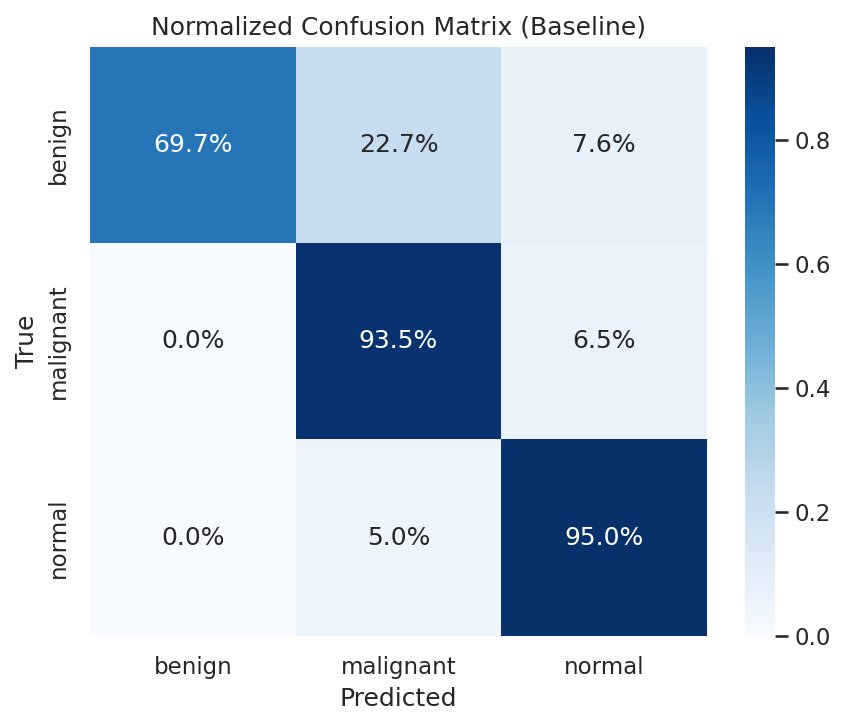

Evaluating models: 100%|██████████| 1/1 [04:53<00:00, 293.27s/it]



✅ Baseline results saved to: /kaggle/working/results/baseline_results.csv


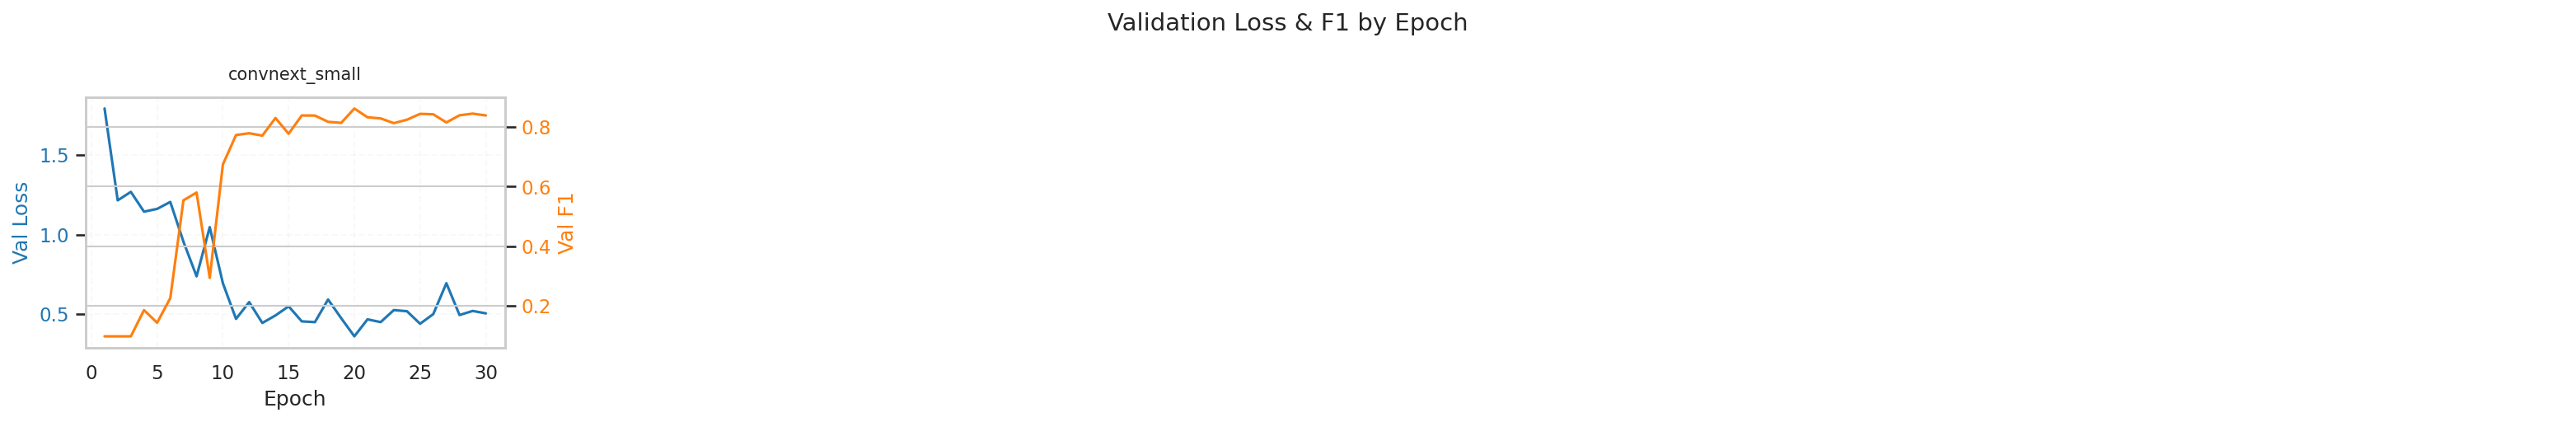


             FINAL TEST PERFORMANCE (BUSI Dataset)
         model  test_accuracy  test_f1  test_auc  test_ece
convnext_small         0.8034   0.8036    0.9561    0.1019

----------------------------------------------------------------------
 BEST MODELS (Test Set):
  F1 🏆       : convnext_small
  Accuracy 🏆 : convnext_small
  AUC 🏆      : convnext_small
  Calibration 🏆 (Lowest ECE): convnext_small
✓ Section 6 complete


In [9]:
import gc
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────
# Section 6: Model Evaluation & Baseline Result Aggregation
# ─────────────────────────────────────────────────────────────────────
all_histories = {}           # Stores training/validation curves
baseline_results = []        # Accumulates test metrics per model
baseline_confusions = {}     # Stores raw confusion matrices

# Loss function (uses class weights from Section 3)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Ensure output directories exist
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['checkpoint_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n✓ Starting evaluation of {len(MODELS)} models on Breast Ultrasound (BUSI)")
print("=" * 80)

# ── Loop over each model ────────────────────────────────────────────
for model_name in tqdm(MODELS, desc='Evaluating models'):
    print(f'\n{"="*60}')
    print(f'  EVALUATING: {model_name}')
    print(f'{"="*60}')
    
    # Train model (from train_model in Section 5)
    try:
        model, history, best_val_metrics = train_model(
            model_name, train_loader, val_loader, class_weights, CONFIG
        )
    except Exception as e:
        print(f"  ❌ Training failed for {model_name}: {e}")
        continue

    all_histories[model_name] = history

    # Load best checkpoint
    ckpt_path = f'{CONFIG["checkpoint_dir"]}/best_busi_{model_name}.pth'
    
    if not Path(ckpt_path).exists():
        print(f"  ❌ Checkpoint not found: {ckpt_path}")
        continue
        
    try:
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        model.eval()
    except Exception as e:
        print(f"  ❌ Failed to load state dict: {e}")
        continue

    # Final test evaluation
    print("  Running test evaluation...")
    test_metrics = evaluate(
        model, test_loader, criterion, device,
        CONFIG['num_classes'], CONFIG['class_names']
    )

    ece_baseline = test_metrics['ece']

    # Apply temperature scaling on validation set for calibration
    try:
        T_val, ece_temp_scaled = temperature_scale(
            model, val_loader, device, CONFIG['num_classes']
        )
        print(
            f"  Temperature = {T_val:.3f}  |  "
            f"ECE_baseline = {ece_baseline:.4f}  |  "
            f"ECE_scaled = {ece_temp_scaled:.4f}"
        )
    except Exception as e:
        print(f"  ⚠️ Temperature scaling failed: {e}")
        T_val = 1.0
        ece_temp_scaled = ece_baseline

    # Confusion Matrix
    y_true = test_metrics['labels']
    y_pred = test_metrics['preds']
    cm = confusion_matrix(
        y_true, y_pred,
        labels=list(range(CONFIG['num_classes']))
    )
    baseline_confusions[model_name] = cm

    # Per-class precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=list(range(CONFIG['num_classes'])),
        zero_division=0
    )
    per_class_metrics = {}
    for i, name in enumerate(CONFIG['class_names']):
        per_class_metrics[f'{name}_precision'] = precision[i]
        per_class_metrics[f'{name}_recall'] = recall[i]
        per_class_metrics[f'{name}_f1'] = f1[i]

    # ✅ Ensure best_val_metrics contains standardized keys
    assert 'val_f1' in best_val_metrics, f"Missing val_f1 in best_val_metrics for {model_name}"
    # Use .get() for defensive programming
    baseline_results.append({
        'model': model_name,
        'val_acc': best_val_metrics.get('val_acc', 0.0),
        'val_f1': best_val_metrics['val_f1'],
        'val_auc': best_val_metrics.get('val_auc', 0.0),
        'val_ece': best_val_metrics.get('val_ece', np.inf),
        'test_accuracy': test_metrics['accuracy'],
        'test_f1': test_metrics['f1'],
        'test_auc': test_metrics.get('auc', np.nan),
        'test_ece': ece_baseline,
        'temperature': T_val,
        'test_ece_temp_scaled': ece_temp_scaled,
        **per_class_metrics
    })

    # Save confusion matrix
    plot_confusion_matrix(
        cm, CONFIG['class_names'], model_name, save=True, suffix='baseline'
    )

    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()


# ─────────────────────────────────────────────────────────────────────
# Save Results and Visualize
# ─────────────────────────────────────────────────────────────────────
if len(baseline_results) == 0:
    print("❌ No models successfully evaluated — nothing to save.")
else:
    # 1. Save to CSV
    baseline_df = pd.DataFrame(baseline_results)
    save_path = f'{CONFIG["results_dir"]}/baseline_results.csv'
    baseline_df.to_csv(save_path, index=False)
    print(f"\n✅ Baseline results saved to: {save_path}")

    # 2. Plot training curves: val_loss + val_f1 per model
    ncols = 5
    nrows = (len(MODELS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.2, nrows * 3.5), dpi=150)
    if nrows == 1:
        axes = np.array([axes]) if ncols > 1 else np.array([[axes]])
    elif ncols == 1:
        axes = axes.reshape(-1)

    for ax, model_name in zip(axes.flat, MODELS):
        if model_name not in all_histories:
            ax.axis('off')
            continue
        hist = all_histories[model_name]
        epochs = np.arange(1, len(hist.get('val_loss', [])) + 1)

        # Left axis: validation loss
        ax.plot(epochs, hist.get('val_loss', []), color='tab:blue', label='Val Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Val Loss', color='tab:blue')
        ax.tick_params(axis='y', labelcolor='tab:blue')

        # Right axis: validation F1
        ax2 = ax.twinx()
        ax2.plot(epochs, hist.get('val_f1', []), color='tab:orange', label='Val F1')
        ax2.set_ylabel('Val F1', color='tab:orange')
        ax2.tick_params(axis='y', labelcolor='tab:orange')

        ax.set_title(model_name, fontsize=10, pad=10)
        ax.grid(True, alpha=0.1, linestyle='--')

    # Turn off unused subplots
    for ax in axes.flat[len(MODELS):]:
        ax.axis('off')

    plt.suptitle("Validation Loss & F1 by Epoch", fontsize=14, y=0.97)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig2_training_curves.png", dpi=300, bbox_inches='tight')
    plt.show()

    # 3. Display concise test results
    print("\n" + "=" * 70)
    print("             FINAL TEST PERFORMANCE (BUSI Dataset)")
    print("=" * 70)
    print(
        baseline_df[['model', 'test_accuracy', 'test_f1', 'test_auc', 'test_ece']]
        .round(4)
        .to_string(index=False)
    )

    # Summary: best model per metric
    print("\n" + "-" * 70)
    print(" BEST MODELS (Test Set):")
    try:
        print(f"  F1 🏆       : {baseline_df.loc[baseline_df['test_f1'].idxmax(), 'model']}")
        print(f"  Accuracy 🏆 : {baseline_df.loc[baseline_df['test_accuracy'].idxmax(), 'model']}")
        print(f"  AUC 🏆      : {baseline_df.loc[baseline_df['test_auc'].idxmax(), 'model']}")
        print(f"  Calibration 🏆 (Lowest ECE): {baseline_df.loc[baseline_df['test_ece'].idxmin(), 'model']}")
    except Exception as e:
        print(f"  ⚠️ Could not determine best models: {e}")

print("✓ Section 6 complete")

In [10]:
import gc
from tqdm import tqdm
import pandas as pd
import torch
import numpy as np
from pathlib import Path

# Ensure results directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────
# extract_failures: Run inference and collect misclassified samples
# Uses val_loader (like Brain MRI & COVID version) for consistent analysis
# ─────────────────────────────────────────────────────────────────────
def extract_failures(model_name, loader, config):
    """
    Load trained model, run inference, extract:
      - Predictions
      - Confidence
      - Probability vectors
      - Embeddings (via forward hook)
    Returns:
      - failures_df: only misclassified samples
      - all_preds_df: all predictions on loader
    """
    model = get_model(model_name, config['num_classes'], pretrained=False)
    ckpt_path = f"{config['checkpoint_dir']}/best_busi_{model_name}.pth"

    if not Path(ckpt_path).exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
        
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    
    # Register embedding hook
    hook_handle, embedding_store = get_embedding_hook(model, model_name)

    rows = []
    with torch.no_grad():
        for images, labels, paths in tqdm(
            loader,
            desc=f'failures {model_name}',
            leave=False,
            disable=not config.get('show_batch_progress', False)
        ):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward pass
            logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            conf = probs.max(axis=1)
            emb_batch = embedding_store['embedding'].numpy()  # Shape: (B, D)

            # Append each sample
            for i in range(len(paths)):
                rows.append({
                    'image_path': paths[i],
                    'true_label': int(labels.cpu().numpy()[i]),
                    'pred_label': int(preds[i]),
                    'confidence': float(conf[i]),
                    'prob_vector': ','.join(f'{p:.8f}' for p in probs[i]),
                    'embedding': ','.join(f'{x:.8f}' for x in emb_batch[i].ravel()),
                })
    # Remove hook
    hook_handle.remove()

    # Create DataFrames
    all_preds_df = pd.DataFrame(rows)
    failures_df = all_preds_df[all_preds_df['true_label'] != all_preds_df['pred_label']].reset_index(drop=True)

    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return failures_df, all_preds_df


# ─────────────────────────────────────────────────────────────────────
# Run: Extract misclassified samples for every model
# Uses val_loader — matches Brain MRI, provides earlier insight than test
# ─────────────────────────────────────────────────────────────────────
all_failures = {}
all_predictions = {}

for model_name in tqdm(MODELS, desc='Extracting failures'):
    try:
        # Use val_loader (aligned with Brain MRI & intent)
        failures_df, all_preds_df = extract_failures(model_name, val_loader, CONFIG)

        # Store
        all_failures[model_name] = failures_df
        all_predictions[model_name] = all_preds_df

        # Save CSVs
        failures_df.to_csv(f"{CONFIG['results_dir']}/failures_busi_{model_name}.csv", index=False)
        all_preds_df.to_csv(f"{CONFIG['results_dir']}/predictions_busi_{model_name}.csv", index=False)

        # Log
        fail_rate = len(failures_df) / len(all_preds_df) if len(all_preds_df) > 0 else 0
        print(f'{model_name}: {len(failures_df)} failures ({fail_rate:.1%})')
    except Exception as e:
        print(f"❌ Failed to extract failures for {model_name}: {e}")

print("✓ Section 7 complete")

Extracting failures:   0%|          | 0/1 [00:00<?, ?it/s]

convnext_small: 49.46M params (49.46M trainable)


Extracting failures: 100%|██████████| 1/1 [00:03<00:00,  3.10s/it]

convnext_small: 17 failures (14.4%)
✓ Section 7 complete



✓ Starting clustering for 1 models on BUSI


Clustering failures:   0%|          | 0/1 [00:00<?, ?it/s]

  🌀 [convnext_small] Clustering 17 failures
  ✅ Parsed 17 × 768d in 0.01s
  📉 PCA reduced to 16d | Explained variance=1.000 | 0.03s
  🔧 Clustering performed in PCA-16d; UMAP only for visualization
  🗺️  PCA-2D completed: 0.00s
  🔍 MiniBatchKMeans sweep (5 values): 0.19s
  ⚠️ K conflict: KMeans=2 | GMM-BIC=5 → keeping silhouette K
  ✅ Final clustering K=2 finished: 0.01s
  🕐 TOTAL time: 0.26s
  🧪 Clustering stability (ARI): [0.3865979381443299, 0.24573378839590443, 0.1296928327645051] → mean=0.254


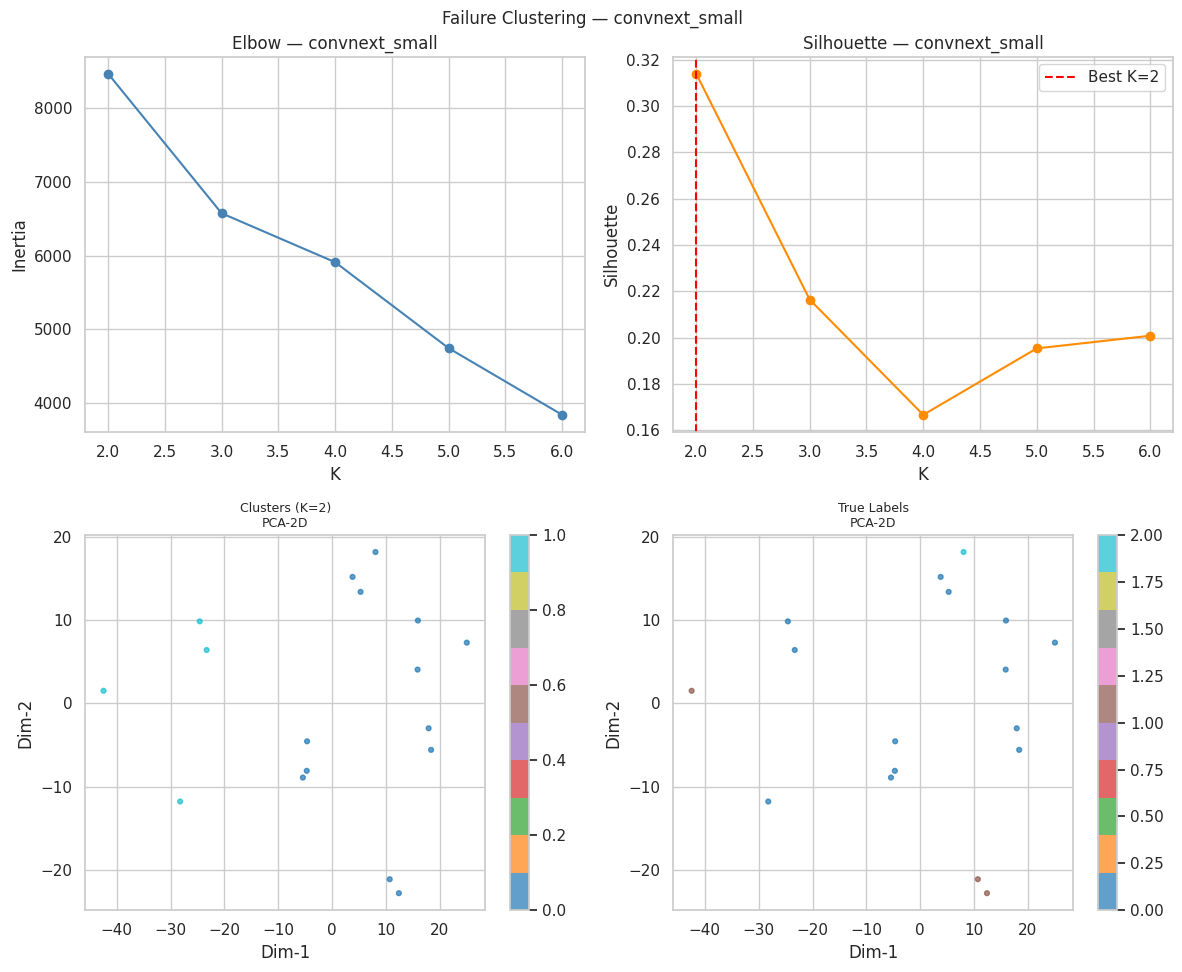

Clustering failures: 100%|██████████| 1/1 [00:01<00:00,  1.56s/it]

  📤 Saved: /kaggle/working/figures/clustering_convnext_small.png
  ✅ convnext_small: K=2 | Silhouette=0.314 | Mean ARI=0.254
✓ Section 8 complete


In [11]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import seaborn as sns
import umap as umap_lib
import gc
from pathlib import Path
from tqdm import tqdm

# Ensure output directories exist
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)


def cluster_failures(failures_df, config, model_name):
    """
    Cluster model failure embeddings using:
      - PCA for dimensionality reduction (config controlled)
      - UMAP for 2D visualization (only if failure count > threshold)
      - MiniBatchKMeans for fast clustering
      - GMM+BIC for secondary validation
      - ARI stability scoring

    Returns:
      clustered_df: DataFrame with `cluster`, `umap_x`, `umap_y`, `best_k_bic`, `mean_ari`
      best_k, best_sil, best_k_bic, mean_ari: summary metrics
    """
    t0 = time.time()

    # ── Guard: Too few failures ──────────────────────────────────
    if len(failures_df) < 3:
        print(f"  🚩 Too few failures ({len(failures_df)}) — skipping: {model_name}")
        out = failures_df.copy().reset_index(drop=True)
        out['cluster'] = 0
        out['umap_x'] = 0.0
        out['umap_y'] = 0.0
        out['mean_ari'] = np.nan
        out['best_k_bic'] = 0
        return out, 1, np.nan, 1, np.nan

    print(f"  🌀 [{model_name}] Clustering {len(failures_df)} failures")

    # ── Parse embeddings: string → numpy array ───────────────────
    raw = failures_df['embedding'].tolist()
    if isinstance(raw[0], str):
        embeddings = np.array(
            [np.fromstring(e, sep=',', dtype=np.float32) for e in raw],
            dtype=np.float32
        )
    else:
        embeddings = np.array(raw, dtype=np.float32)
    print(f"  ✅ Parsed {len(embeddings)} × {embeddings.shape[1]}d in {time.time()-t0:.2f}s")

    # ── PCA: aggressive dimensionality reduction ──────────────────
    t1 = time.time()
    scaler = StandardScaler()
    E_scaled = scaler.fit_transform(embeddings)

    n_pca = min(
        config.get('pca_components', 32),
        len(failures_df) - 1,
        E_scaled.shape[1]
    )
    pca = PCA(
        n_components=n_pca,
        random_state=config['seed'],
        svd_solver='randomized'
    )
    E_pca = pca.fit_transform(E_scaled).astype(np.float32)
    ratio = pca.explained_variance_ratio_.sum()
    print(f"  📉 PCA reduced to {n_pca}d | Explained variance={ratio:.3f} | {time.time()-t1:.2f}s")
    print(f"  🔧 Clustering performed in PCA-{n_pca}d; UMAP only for visualization")

    # ── UMAP: 2D projection only when sample size justifies it ─────
    t2 = time.time()
    UMAP_THRESHOLD = config.get('small_failure_umap_threshold', 300)
    if len(failures_df) < UMAP_THRESHOLD:
        E_2d = E_pca[:, :2]
        proj_method = 'PCA-2D'
    else:
        n_neighbors = min(10, max(2, len(failures_df) - 1))
        reducer = umap_lib.UMAP(
            n_neighbors=n_neighbors,
            min_dist=config.get('umap_min_dist', 0.1),
            n_components=2,
            random_state=config['seed'],
            low_memory=True,
            n_epochs=50,
            metric='euclidean',
            n_jobs=1
        )
        # Speed: reduce to 16d PCA output before UMAP
        E_umap_input = E_pca[:, :16] if E_pca.shape[1] >= 16 else E_pca
        E_2d = reducer.fit_transform(E_umap_input).astype(np.float32)
        proj_method = 'UMAP'

    print(f"  🗺️  {proj_method} completed: {time.time()-t2:.2f}s")

    # ── KMeans sweep: MiniBatchKMeans + silhouette ───────────────
    t3 = time.time()
    k_range = list(config.get('k_range', range(2, 7)))
    k_range = [k for k in k_range if 2 <= k <= min(6, len(failures_df) - 1)]
    if not k_range:
        k_range = [2] if len(failures_df) >= 2 else []

    inertias, silhouettes, valid_k = [], [], []
    MAX_SIL_SAMPLES = 500
    sil_idx = (
        np.random.RandomState(config['seed'])
        .choice(len(E_pca), size=min(MAX_SIL_SAMPLES, len(E_pca)), replace=False)
        if len(E_pca) > MAX_SIL_SAMPLES else np.arange(len(E_pca))
    )
    E_sil = E_pca[sil_idx]

    for k in k_range:
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=config['seed'],
            n_init=3,
            batch_size=min(256, len(failures_df)),
            max_iter=100
        )
        labels = km.fit_predict(E_pca)
        inertias.append(km.inertia_)
        valid_k.append(k)

        labels_sil = labels[sil_idx]
        if len(set(labels_sil)) > 1:
            sil_score = silhouette_score(E_sil, labels_sil, sample_size=None)
            silhouettes.append(sil_score)
        else:
            silhouettes.append(np.nan)

    print(f"  🔍 MiniBatchKMeans sweep ({len(k_range)} values): {time.time()-t3:.2f}s")

    # ── Select best K from silhouette ────────────────────────────
    if silhouettes and not np.all(np.isnan(silhouettes)):
        best_idx = int(np.nanargmax(silhouettes))
        best_k = valid_k[best_idx]
        best_sil = silhouettes[best_idx]
    else:
        best_k = 2
        best_sil = np.nan

    # ── GMM for BIC validation ──────────────────────────────────
    bic_scores = []
    best_k_bic = best_k
    if len(E_pca) >= 10 and k_range:
        for k in k_range:
            try:
                gmm = GaussianMixture(
                    n_components=k,
                    random_state=config['seed'],
                    max_iter=50,
                    n_init=2,
                    covariance_type='diag'
                )
                gmm.fit(E_pca)
                bic_scores.append(gmm.bic(E_pca))
            except Exception:
                bic_scores.append(np.inf)

        if bic_scores:
            best_k_bic = k_range[int(np.argmin(bic_scores))]

        if best_k_bic == best_k:
            print(f"  ✅ K consensus: KMeans={best_k} | GMM-BIC={best_k_bic}")
        else:
            print(f"  ⚠️ K conflict: KMeans={best_k} | GMM-BIC={best_k_bic} → keeping silhouette K")
    else:
        print("  📊 GMM BIC skipped (n_samples too low)")

    # ── Final clustering with best K ────────────────────────────
    t4 = time.time()
    final_km = MiniBatchKMeans(
        n_clusters=best_k,
        random_state=config['seed'],
        n_init=5,
        batch_size=min(512, len(failures_df))
    )
    cluster_labels = final_km.fit_predict(E_pca)
    print(f"  ✅ Final clustering K={best_k} finished: {time.time()-t4:.2f}s")
    print(f"  🕐 TOTAL time: {time.time()-t0:.2f}s")

    # ── Attach results to DataFrame ─────────────────────────────
    clustered = failures_df.copy().reset_index(drop=True)
    clustered['cluster'] = cluster_labels
    clustered['umap_x'] = E_2d[:, 0]
    clustered['umap_y'] = E_2d[:, 1]

    # ── Clustering stability: ARI across seeds ────────────────────
    ari_scores = []
    for seed_i in [0, 1, 2]:  # Multiple random runs
        km_test = MiniBatchKMeans(
            n_clusters=best_k,
            random_state=seed_i,
            n_init=3,
            batch_size=min(256, len(failures_df))
        )
        labels_test = km_test.fit_predict(E_pca)
        ari = adjusted_rand_score(cluster_labels, labels_test)
        ari_scores.append(ari)
    mean_ari = float(np.mean(ari_scores))
    print(f"  🧪 Clustering stability (ARI): {ari_scores} → mean={mean_ari:.3f}")
    clustered['mean_ari'] = mean_ari
    clustered['best_k_bic'] = best_k_bic

    # ── Plotting ────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Elbow Plot
    if len(valid_k) > 1:
        axes[0, 0].plot(valid_k, inertias, marker='o', color='steelblue')
    axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')
    axes[0, 0].set_title(f'Elbow — {model_name}')

    # Silhouette Plot
    if len(valid_k) > 1:
        axes[0, 1].plot(valid_k, silhouettes, marker='o', color='darkorange')
        axes[0, 1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
        axes[0, 1].legend()
    axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Silhouette')
    axes[0, 1].set_title(f'Silhouette — {model_name}')

    # Cluster Assignments
    sc1 = axes[1, 0].scatter(
        clustered['umap_x'], clustered['umap_y'],
        c=clustered['cluster'], cmap='tab10', s=12, alpha=0.7
    )
    axes[1, 0].set_title(f'Clusters (K={best_k})\n{proj_method}', fontsize=9)
    axes[1, 0].set_xlabel('Dim-1'); axes[1, 0].set_ylabel('Dim-2')
    plt.colorbar(sc1, ax=axes[1, 0])

    # True Labels
    sc2 = axes[1, 1].scatter(
        clustered['umap_x'], clustered['umap_y'],
        c=clustered['true_label'], cmap='tab10', s=12, alpha=0.7
    )
    axes[1, 1].set_title(f'True Labels\n{proj_method}', fontsize=9)
    axes[1, 1].set_xlabel('Dim-1'); axes[1, 1].set_ylabel('Dim-2')
    plt.colorbar(sc2, ax=axes[1, 1])

    plt.suptitle(f"Failure Clustering — {model_name}", fontsize=12, y=0.97)
    plt.tight_layout()
    save_path = f"{config['figures_dir']}/clustering_{model_name}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  📤 Saved: {save_path}")

    return clustered, best_k, best_sil, best_k_bic, mean_ari


# ────────────────────────────────────────────────────────────────
# Run Clustering on All Models (BUSI)
# ────────────────────────────────────────────────────────────────
all_clustered = {}
cluster_summaries = {}

print(f"\n✓ Starting clustering for {len(MODELS)} models on BUSI")
print("=" * 80)

for model_name in tqdm(MODELS, desc="Clustering failures"):
    if model_name not in all_failures or len(all_failures[model_name]) == 0:
        print(f"  ❌ No failures found for {model_name}")
        continue

    try:
        clustered_df, best_k, sil, best_k_bic, mean_ari = cluster_failures(
            all_failures[model_name], CONFIG, model_name
        )
        all_clustered[model_name] = clustered_df
        cluster_summaries[model_name] = {
            'best_k': int(best_k),
            'silhouette': sil,
            'best_k_bic': int(best_k_bic),
            'mean_ari': mean_ari,
        }

        # Save to results
        save_path = f"{CONFIG['results_dir']}/clustered_failures_busi_{model_name}.csv"
        clustered_df.to_csv(save_path, index=False)

        sil_str = f"{sil:.3f}" if not np.isnan(sil) else "N/A"
        print(f"  ✅ {model_name}: K={best_k} | Silhouette={sil_str} | Mean ARI={mean_ari:.3f}")

    except Exception as e:
        print(f"  ❌ Failed to cluster {model_name}: {e}")

# Save cluster summary
summary_df = pd.DataFrame(cluster_summaries).T
summary_df.to_csv(f"{CONFIG['results_dir']}/clustering_summary_busi.csv")

print("✓ Section 8 complete")


✓ Starting failure profiling for 1 models on BUSI


Profiling clusters:   0%|          | 0/1 [00:00<?, ?it/s]


 Profiling → convnext_small
  📏 Image features: brightness=mean/255, contrast=std/255, sharpness=var(Laplacian), foreground_size=pixels > mean

    CLUSTER PROFILE SUMMARY
 cluster  n_samples dominant_confusion  mean_confidence  per_cluster_ece
       0         13  benign->malignant         0.801291         0.801291
       1          4  benign->malignant         0.663153         0.663153


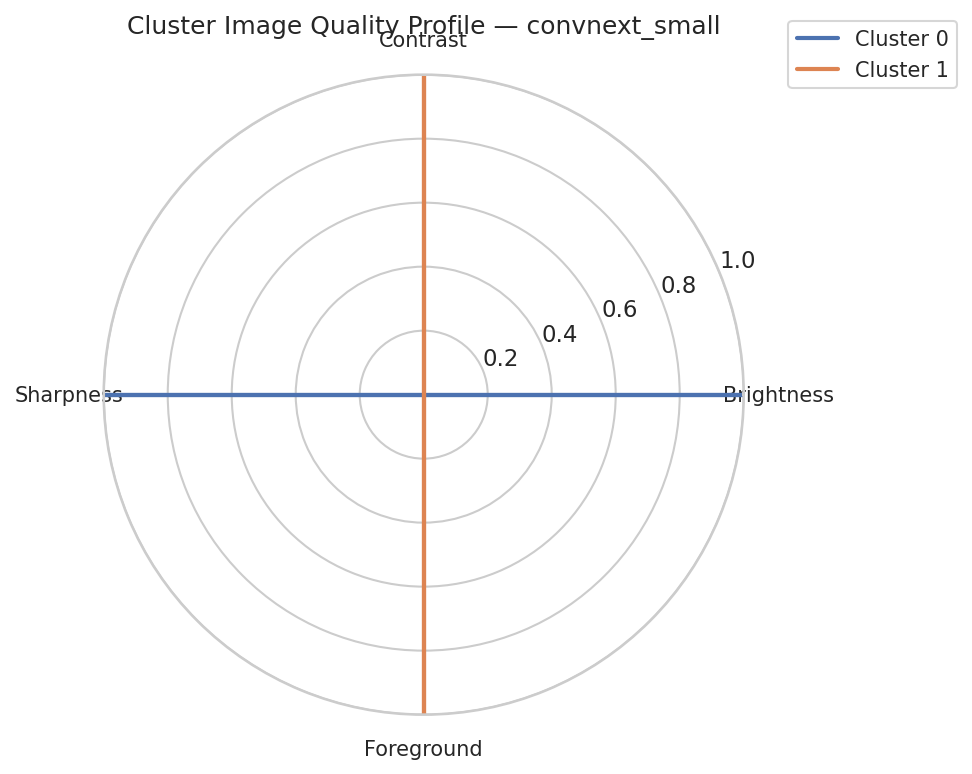

Profiling clusters: 100%|██████████| 1/1 [00:00<00:00,  1.39it/s]

  📈 Radar plot saved: /kaggle/working/figures/radar_convnext_small.png
  ✅ Profile saved: /kaggle/working/results/profile_busi_convnext_small.csv

📊 Cached image features: 17 unique images
✓ Section 9 complete


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
from collections import Counter
from tqdm import tqdm
from PIL import Image
from pathlib import Path

# Global cache for expensive image features (shared across all models)
IMAGE_FEATURE_CACHE = {}


def compute_image_features(image_path, image_dir=None):
    """
    Compute fast, modality-robust image features: brightness, contrast, sharpness,
    and foreground size (via mean-intensity thresholding). Cached for efficiency.
    """
    if image_path in IMAGE_FEATURE_CACHE:
        return IMAGE_FEATURE_CACHE[image_path]

    try:
        img = Image.open(image_path).convert('L')  # Grayscale
        img = img.resize((224, 224), Image.BILINEAR)
        arr = np.asarray(img, dtype=np.float32)
    except Exception as exc:
        features = {
            'brightness': np.nan,
            'contrast': np.nan,
            'sharpness': np.nan,
            'foreground_size': np.nan,
        }
        IMAGE_FEATURE_CACHE[image_path] = features
        return features

    # 1. Brightness: mean intensity (normalized to [0,1])
    brightness = float(arr.mean() / 255.0)

    # 2. Contrast: std of intensity (normalized)
    contrast = float(arr.std() / 255.0)

    # 3. Sharpness: Laplacian variance (edge content)
    if ndimage is not None:
        sharpness = float(np.var(ndimage.laplace(arr)))
    else:
        gy, gx = np.gradient(arr)
        sharpness = float(np.var(gx) + np.var(gy))

    # 4. Foreground proxy: fraction of pixels brighter than mean
    # Robust threshold (no Otsu or fixed threshold)
    if arr.std() > 1.0:
        foreground_size = float((arr > arr.mean()).mean())
    else:
        foreground_size = 0.0  # Uniform/flat image

    features = {
        'brightness': brightness,
        'contrast': contrast,
        'sharpness': sharpness,
        'foreground_size': foreground_size,
    }

    IMAGE_FEATURE_CACHE[image_path] = features
    return features


def profile_clusters(clustered_df, model_name, config):
    """
    Compute per-cluster statistics on image quality, confusion patterns, and calibration.
    Returns a DataFrame summarizing each cluster's failure behavior.
    """
    print(f"  📏 Image features: brightness=mean/255, contrast=std/255, "
          f"sharpness=var(Laplacian), foreground_size=pixels > mean")

    rows = []

    if len(clustered_df) == 0:
        print(f"  🚫 No clustered failures for {model_name}")
        return pd.DataFrame()

    class_map = dict(enumerate(config['class_names']))

    for cluster_id, group in tqdm(
        clustered_df.groupby('cluster'),
        desc=f'profile {model_name}',
        leave=False,
        disable=not config.get('show_batch_progress', False)
    ):
        # Convert probabilistic outputs
        probs = np.stack(
            group['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))
        )
        labels_arr = group['true_label'].values

        # Dominant confusion pattern (most frequent true→pred)
        pairs = list(zip(group['true_label'], group['pred_label']))
        dominant_pair = Counter(pairs).most_common(1)[0][0]
        from_class = config['class_names'][dominant_pair[0]]
        to_class = config['class_names'][dominant_pair[1]]
        confusion_label = f"{from_class}->{to_class}"

        # Image quality features
        feature_rows = [
            compute_image_features(p, config.get('image_dir'))
            for p in group['image_path']
        ]
        features_df = pd.DataFrame(feature_rows)

        row = {
            'cluster': int(cluster_id),
            'n_samples': int(len(group)),
            'true_class_distribution': dict(Counter(group['true_label'].map(class_map))),
            'pred_class_distribution': dict(Counter(group['pred_label'].map(class_map))),
            'dominant_confusion': confusion_label,
            'mean_confidence': float(group['confidence'].mean()),
            'std_confidence': float(group['confidence'].std(ddof=0)),
            'per_cluster_ece': compute_ece(probs, labels_arr, config['ece_bins'])
        }

        # Aggregate image features
        for feat in ['brightness', 'contrast', 'sharpness', 'foreground_size']:
            row[f'{feat}_mean'] = float(features_df[feat].mean())
            row[f'{feat}_std'] = float(features_df[feat].std(ddof=0))

        rows.append(row)

    profile_df = pd.DataFrame(rows)

    # Print cluster summary
    if not profile_df.empty:
        print("\n" + "="*60)
        print("    CLUSTER PROFILE SUMMARY")
        print("="*60)
        print(profile_df[[
            'cluster', 'n_samples', 'dominant_confusion',
            'mean_confidence', 'per_cluster_ece'
        ]].to_string(index=False))

    # Radar Plot: Visualize cluster-wise image feature differences
    feats = ['brightness_mean', 'contrast_mean', 'sharpness_mean', 'foreground_size_mean']

    if not profile_df.empty and len(profile_df) > 1:
        radar = profile_df[['cluster'] + feats].copy()

        # Normalize each feature to [0, 1] across clusters
        for feat in feats:
            mn, mx = radar[feat].min(), radar[feat].max()
            if pd.isna(mn) or pd.isna(mx) or mx <= mn:
                radar[feat] = 0.5
            else:
                radar[feat] = (radar[feat] - mn) / (mx - mn)

        labels = ['Brightness', 'Contrast', 'Sharpness', 'Foreground']
        angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
        angles += angles[:1]  # Close the loop

        fig = plt.figure(figsize=(7, 7), dpi=150)
        ax = fig.add_subplot(111, polar=True)

        for _, row in radar.iterrows():
            values = [row[feat] for feat in feats] + [row[feats[0]]]
            ax.plot(angles, values, linewidth=2, label=f"Cluster {int(row['cluster'])}")
            ax.fill(angles, values, alpha=0.08)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_title(f"Cluster Image Quality Profile — {model_name}", pad=20, fontsize=12)
        ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

        plt.tight_layout()
        save_path = f"{config['figures_dir']}/radar_{model_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"  📈 Radar plot saved: {save_path}")
    elif not profile_df.empty:
        print(f"  📝 Only one cluster — skipping radar plot (requires ≥2)")
    else:
        print(f"  🚫 No valid clusters — skipping radar")

    return profile_df


# ===================================================================
#             Run Profiling for All Models (Breast Ultrasound)
# ===================================================================
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

all_profiles = {}

print(f"\n✓ Starting failure profiling for {len(MODELS)} models on BUSI")
print("=" * 80)

for model_name in tqdm(MODELS, desc='Profiling clusters'):
    if model_name not in all_clustered or len(all_clustered[model_name]) == 0:
        print(f"  ❌ No clustered failures for {model_name}")
        continue

    try:
        print(f'\n{"="*50}')
        print(f' Profiling → {model_name}')
        print(f'{"="*50}')

        profile_df = profile_clusters(all_clustered[model_name], model_name, CONFIG)
        all_profiles[model_name] = profile_df

        # Save profile with BUSI-identifying name
        save_path = f'{CONFIG["results_dir"]}/profile_busi_{model_name}.csv'
        profile_df.to_csv(save_path, index=False)
        print(f"  ✅ Profile saved: {save_path}")

    except Exception as e:
        print(f"  ❌ Failed to profile {model_name}: {e}")

# Final cache size report
print(f"\n📊 Cached image features: {len(IMAGE_FEATURE_CACHE)} unique images")
print("✓ Section 9 complete")

In [13]:
# ─────────────────────────────────────────────────────────────────────
# Section 10: Failure-Aware Retraining & Degradation Guard
# Aligns with CONFIG and matches behavior across datasets
# ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict
from pathlib import Path
from tqdm import tqdm
import gc

# ── 1. Failure-Aware Dataset Builder ──────────────────────────────
def build_failure_aware_dataset(train_df, clustered_df, profile_df, config, strategy='both'):
    """
    Enhance training set using cluster insights: augmentation, weighting, or both.
    """
    out = train_df.copy()
    out['is_augmented'] = False
    out['sample_weight'] = 1.0

    if (clustered_df is None or len(clustered_df) == 0 or
        profile_df is None or len(profile_df) == 0):
        return out

    cluster_counts = clustered_df['cluster'].value_counts().to_dict()
    mean_cluster_count = np.mean(list(cluster_counts.values())) if cluster_counts else 1.0

    cluster_alpha = {
        k: max(1.0, v / max(mean_cluster_count, 1e-8))
        for k, v in cluster_counts.items()
    }

    path_to_cluster = dict(zip(clustered_df['image_path'], clustered_df['cluster']))

    cluster_to_true_labels = (
        clustered_df
        .groupby('cluster')['true_label']
        .apply(lambda s: set(s.tolist()))
        .to_dict()
    )

    path_overlap = out['image_path'].isin(set(clustered_df['image_path'])).sum()

    # ── Selective Augmentation (for CNNs) ──────────────────────────
    if strategy in ['selective', 'both']:
        high_clusters = [k for k, v in cluster_counts.items() if v > mean_cluster_count]
        if len(high_clusters) == 0:
            high_clusters = list(cluster_counts.keys())

        high_paths = set(clustered_df[clustered_df['cluster'].isin(high_clusters)]['image_path'])
        source = out[out['image_path'].isin(high_paths)].copy()

        if len(source) == 0:
            high_labels = set()
            for cid in high_clusters:
                high_labels.update(cluster_to_true_labels.get(cid, set()))
            source = out[out['label'].isin(high_labels)].copy()
            print(
                "No train/test path overlap — using high-error labels: "
                f"{sorted(high_labels)}."
            )

        max_aug_source = config.get('max_aug_source', 300)
        if len(source) > max_aug_source:
            if source['label'].nunique() > 1:
                source, _ = train_test_split(
                    source,
                    train_size=max_aug_source,
                    random_state=config['seed'],
                    stratify=source['label']
                )
            else:
                source = source.sample(n=max_aug_source, random_state=config['seed'])
            source = source.reset_index(drop=True)
            print(f"Selective source limited to {max_aug_source} samples.")

        # Apply heavy augmentation to source
        augmented = [source.copy() for _ in range(config.get('aug_multiplier', 3))]
        for a in augmented:
            a['is_augmented'] = True

        out = pd.concat([out] + augmented, ignore_index=True)

        print(
            f"Selective augmentation: {len(source)} source → "
            f"{sum(len(a) for a in augmented)} augmented added"
        )

    # ── Weighted Sampling (for Transformers & EfficientNet) ────────
    if strategy in ['weighted', 'both']:
        if path_overlap > 0:
            out['sample_weight'] = out['image_path'].map(
                lambda p: cluster_alpha.get(path_to_cluster.get(p, None), 1.0)
            )
        else:
            label_weights = defaultdict(lambda: 1.0)
            for cid, alpha in cluster_alpha.items():
                for label in cluster_to_true_labels.get(cid, set()):
                    label_weights[label] = max(label_weights[label], alpha)
            out['sample_weight'] = out['label'].map(lambda y: label_weights[y])

            print(
                "No path overlap — using per-label weights: "
                f"{dict(label_weights)}"
            )

        print(
            f"Weighted sampling: sample weights range "
            f"{out['sample_weight'].min():.2f}–{out['sample_weight'].max():.2f}"
        )

    return out


# ── 2. Degradation Guard with Tiered Thresholds ──────────────────
def _run_degradation_guard(
    model, model_name, val_loader, criterion_retrain,
    baseline_val_metrics, config, device,
    baseline_ckpt, retrained_ckpt
):
    """Revert to baseline if retrained model regresses on any metric."""
    val_retrained = evaluate(
        model, val_loader, criterion_retrain,
        device, config['num_classes'], config['class_names']
    )

    baseline_f1 = baseline_val_metrics['val_f1']
    use_weak = baseline_f1 < config.get('guard_weak_baseline_f1', 0.55)

    if use_weak:
        max_f1_drop = config.get('guard_weak_f1_max_drop', 0.04)
        max_acc_drop = config.get('guard_weak_acc_max_drop', 0.04)
        max_ece_rise = config.get('guard_weak_ece_max_rise', 0.04)
        tier = 'WEAK'
    else:
        max_f1_drop = config.get('guard_f1_max_drop', 0.02)
        max_acc_drop = config.get('guard_acc_max_drop', 0.02)
        max_ece_rise = config.get('guard_ece_max_rise', 0.025)
        tier = 'STRICT'

    f1_drop = baseline_val_metrics['val_f1'] - val_retrained['f1']
    acc_drop = baseline_val_metrics['val_acc'] - val_retrained['accuracy']
    ece_rise = val_retrained['ece'] - baseline_val_metrics['val_ece']

    checks = {
        'f1_ok': (
            f1_drop <= max_f1_drop,
            f"val F1 drop {f1_drop:+.4f} {'≤' if f1_drop <= max_f1_drop else '>'} {max_f1_drop} [{tier}]"
        ),
        'acc_ok': (
            acc_drop <= max_acc_drop,
            f"acc drop {acc_drop:+.4f} {'≤' if acc_drop <= max_acc_drop else '>'} {max_acc_drop} [{tier}]"
        ),
        'ece_ok': (
            ece_rise <= max_ece_rise,
            f"ECE rise {ece_rise:+.4f} {'≤' if ece_rise <= max_ece_rise else '>'} {max_ece_rise} [{tier}]"
        ),
    }

    print(f"  Guard checks — {model_name}:")
    for name, (passed, msg) in checks.items():
        print(f"    {'✓' if passed else '✗'}  {msg}")

    failed = [msg for passed, msg in checks.values() if not passed]

    if failed:
        print(f"\n  ⚠️  Guard triggered — reverting {model_name} to baseline")
        model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
        torch.save(model.state_dict(), retrained_ckpt)  # keep saved
        return {
            'guard_triggered': True,
            'kept': 'baseline',
            'checks': {k: v[1] for k, v in checks.items()},
            'reason': ' | '.join(failed),
        }

    print(f"\n  ✓ All checks passed — keeping retrained {model_name}")
    return {
        'guard_triggered': False,
        'kept': 'retrained',
        'checks': {k: v[1] for k, v in checks.items()},
        'reason': None,
    }


# ── 3. Main Retraining Loop ─────────────────────────────────────────
def retrain_model(
    model_name, train_loader_new, val_loader, class_weights, config,
    baseline_val_metrics=None
):
    """Fine-tune model with failure-aware data and degradation guard."""
    baseline_ckpt = Path(config['checkpoint_dir']) / f"best_busi_{model_name}.pth"
    retrained_ckpt = Path(config['checkpoint_dir']) / f"retrained_busi_{model_name}.pth"

    # Warm start from best baseline
    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    model.train()

    criterion_retrain = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.get('retrain_epochs', 10)
    )
    scaler = GradScaler()

    # Training loop
    history = defaultdict(list)
    best_f1 = -np.inf
    patience_counter = 0
    retrain_epochs = config.get('retrain_epochs', 10)
    retrain_patience = config.get('retrain_patience', 3)

    for epoch in range(1, retrain_epochs + 1):
        print(f"  Retrain epoch {epoch}/{retrain_epochs} — {model_name}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader_new, optimizer,
            criterion_retrain, scaler, device
        )

        val_metrics = evaluate(
            model, val_loader, criterion_retrain, device,
            config['num_classes'], config['class_names']
        )

        scheduler.step()

        # Track history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])

        print(
            f"    loss={val_metrics['loss']:.4f}  "
            f"acc={val_metrics['accuracy']:.4f}  "
            f"F1={val_metrics['f1']:.4f}  "
            f"AUC={val_metrics['auc']:.4f}"
        )

        # Save best
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), retrained_ckpt)
            print(f"    ✓ Checkpoint saved (best val F1={best_f1:.4f})")
        else:
            patience_counter += 1
            print(f"    patience {patience_counter}/{retrain_patience}")
            if patience_counter >= retrain_patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    # Load best weights before guard
    model.load_state_dict(torch.load(retrained_ckpt, map_location=device))

    # Run guard
    if baseline_val_metrics is not None:
        guard_result = _run_degradation_guard(
            model, model_name, val_loader, criterion_retrain,
            baseline_val_metrics, config, device,
            baseline_ckpt, retrained_ckpt
        )
    else:
        print(f"\n  ⚠️ Guard skipped — no baseline metrics for {model_name}")
        guard_result = {
            'guard_triggered': False,
            'kept': 'retrained',
            'checks': {},
            'reason': 'Guard skipped — no val metrics',
        }

    return model, dict(history), guard_result


# ─────────────────────────────────────────────────────────────────────
# Run Retraining for All Models (BUSI)
# ─────────────────────────────────────────────────────────────────────
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

improvement_results = []
retrain_histories = {}
retrained_confusions = {}
retrained_predictions = {}
guard_log = []

for model_name in tqdm(MODELS, desc='Retraining'):
    family = get_model_family(model_name)
    strategy = {
        'transformer': 'both',
        'efficient': 'weighted',
        'cnn': 'selective'
    }[family]

    print(f'\n{"═"*60}')
    print(f'Retraining → {model_name} | family={family} | strategy={strategy}')
    print(f'{"═"*60}')

    # Build failure-aware training set
    new_train_df = build_failure_aware_dataset(
        train_df,
        all_clustered[model_name],
        all_profiles[model_name],
        CONFIG,
        strategy
    )

    # Create new DataLoaders
    new_train_loader, _, _, _ = get_dataloaders(
        new_train_df,
        test_df,
        CONFIG,
        val_df=val_loader.dataset.df
    )

    # Load baseline val metrics (fallback to test if missing)
    baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
    baseline_val_metrics = {
        'val_f1': baseline_row.get('val_f1', baseline_row['test_f1']),
        'val_acc': baseline_row.get('val_acc', baseline_row['test_accuracy']),
        'val_ece': baseline_row.get('val_ece', baseline_row['test_ece']),
    }

    # Retrain with guard
    retrained_model, history, guard_result = retrain_model(
        model_name,
        new_train_loader,
        val_loader,
        class_weights,
        CONFIG,
        baseline_val_metrics=baseline_val_metrics
    )

    retrain_histories[model_name] = history
    guard_log.append({**guard_result, 'model': model_name})

    # Final test evaluation
    retrain_metrics = evaluate(
        retrained_model,
        test_loader,
        criterion,
        device,
        CONFIG['num_classes'],
        CONFIG['class_names']
    )
    retrained_predictions[model_name] = retrain_metrics

    # Confusion matrix
    retrained_confusions[model_name] = confusion_matrix(
        retrain_metrics['labels'],
        retrain_metrics['preds'],
        labels=list(range(CONFIG['num_classes']))
    )

    # Improvement deltas
    def compute_delta(new, base):
        return (new - base) / max(base, 1e-8) * 100

    improvement_results.append({
        'model': model_name,
        'family': family,
        'strategy': strategy,
        'guard_triggered': guard_result['guard_triggered'],
        'guard_kept': guard_result['kept'],
        'guard_reason': guard_result['reason'],
        # Accuracy
        'baseline_acc': baseline_row['test_accuracy'],
        'retrained_acc': retrain_metrics['accuracy'],
        'delta_acc_pct': compute_delta(retrain_metrics['accuracy'], baseline_row['test_accuracy']),
        # F1
        'baseline_f1': baseline_row['test_f1'],
        'retrained_f1': retrain_metrics['f1'],
        'delta_f1_pct': compute_delta(retrain_metrics['f1'], baseline_row['test_f1']),
        # AUC
        'baseline_auc': baseline_row['test_auc'],
        'retrained_auc': retrain_metrics['auc'],
        'delta_auc_pct': compute_delta(retrain_metrics['auc'], baseline_row['test_auc']),
        # ECE
        'baseline_ece': baseline_row['test_ece'],
        'retrained_ece': retrain_metrics['ece'],
        'delta_ece': retrain_metrics['ece'] - baseline_row['test_ece'],
    })

    # Cleanup
    del retrained_model
    torch.cuda.empty_cache()
    gc.collect()


# ─────────────────────────────────────────────────────────────────────
# Save Results
# ─────────────────────────────────────────────────────────────────────
improvement_df = pd.DataFrame(improvement_results)
improvement_df.to_csv(f'{CONFIG["results_dir"]}/improvement_busi.csv', index=False)

guard_df = pd.DataFrame(guard_log)
guard_df.to_csv(f'{CONFIG["results_dir"]}/guard_log_busi.csv', index=False)


# ─────────────────────────────────────────────────────────────────────
# Summaries
# ─────────────────────────────────────────────────────────────────────
triggered = guard_df[guard_df['guard_triggered']]
passed = guard_df[~guard_df['guard_triggered']]

print(f'\n{"═"*60}')
print('GUARD SUMMARY')
print(f'{"═"*60}')
print(f'  Passed   (kept retrained) : {len(passed)}/{len(MODELS)}')
print(f'  Triggered (reverted)      : {len(triggered)}/{len(MODELS)}')
if len(triggered) > 0:
    print(f'\n  Reverted Models:')
    for _, row in triggered.iterrows():
        print(f'    ⚠️  {row["model"]:35s}  {row["reason"]}')

print(f'\n{"═"*60}')
print('IMPROVEMENT SUMMARY (Test Set)')
print(f'{"═"*60}')
print(improvement_df[[
    'model', 'strategy', 'guard_kept',
    'baseline_acc', 'retrained_acc', 'delta_acc_pct',
    'baseline_f1', 'retrained_f1', 'delta_f1_pct',
    'delta_ece',
]].round(4).to_string(index=False))

print('\n✓ Section 10 complete')

Retraining:   0%|          | 0/1 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
Retraining → convnext_small | family=transformer | strategy=both
════════════════════════════════════════════════════════════
No train/test path overlap — using high-error labels: [0, 1, 2].
Selective source limited to 300 samples.
Selective augmentation: 300 source → 900 augmented added
No path overlap — using per-label weights: {0: np.float64(1.5294117647058822), 1: np.float64(1.5294117647058822), 2: np.float64(1.5294117647058822)}
Weighted sampling: sample weights range 1.53–1.53
convnext_small: 49.46M params (49.46M trainable)
  Retrain epoch 1/20 — convnext_small
    loss=0.6874  acc=0.8559  F1=0.8360  AUC=0.9570
    ✓ Checkpoint saved (best val F1=0.8360)
  Retrain epoch 2/20 — convnext_small
    loss=0.5456  acc=0.7881  F1=0.7967  AUC=0.9405
    patience 1/10
  Retrain epoch 3/20 — convnext_small
    loss=0.4610  acc=0.8644  F1=0.8624  AUC=0.9586
    ✓ Checkpoint saved (best val F1=0.8624)
  Retrain epoch 4/20 — convn

Retraining: 100%|██████████| 1/1 [06:08<00:00, 368.74s/it]


════════════════════════════════════════════════════════════
GUARD SUMMARY
════════════════════════════════════════════════════════════
  Passed   (kept retrained) : 0/1
  Triggered (reverted)      : 1/1

  Reverted Models:
    ⚠️  convnext_small                       ECE rise +0.0117 > 0.01 [STRICT]

════════════════════════════════════════════════════════════
IMPROVEMENT SUMMARY (Test Set)
════════════════════════════════════════════════════════════
         model strategy guard_kept  baseline_acc  retrained_acc  delta_acc_pct  baseline_f1  retrained_f1  delta_f1_pct  delta_ece
convnext_small     both   baseline        0.8034         0.8034            0.0       0.8036        0.8036           0.0        0.0

✓ Section 10 complete


In [14]:
# ─────────────────────────────────────────────────────────────────────
# Section 10b: Compute-Matched Untargeted Control (BUSI)
# Same retraining budget as Section 10, but no failure-aware strategies.
# Measures improvement from extra training alone (baseline comparison).
# ─────────────────────────────────────────────────────────────────────
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict
from pathlib import Path
from tqdm import tqdm
import gc

# Dataset identifiers (for multi-dataset results merging)
DATASET_NAME = 'busi'
DATASET_DISPLAY = 'Breast Ultrasound (BUSI)'


def retrain_untargeted(model_name, train_loader, val_loader, class_weights, config):
    """
    Run untargeted retraining control:
      - Warm-starts from best baseline model
      - Uses the same: epochs, LR, scheduler, and optimizer as retraining
      - No failure-awareness: no clustering, weighting, or augmentation
      - Identical training loop (except data)
    Returns full test metrics.
    """
    baseline_ckpt = Path(config['checkpoint_dir']) / f"best_busi_{model_name}.pth"
    control_ckpt = Path(config['checkpoint_dir']) / f"control_busi_{model_name}.pth"

    # Load and initialize
    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    model.train()

    # Same loss, optimizer, schedule as failure-aware retraining
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.get('retrain_epochs', 10)
    )
    scaler = GradScaler()

    # Training loop
    best_f1 = -np.inf
    patience_counter = 0
    retrain_epochs = config.get('retrain_epochs', 10)
    retrain_patience = config.get('retrain_patience', 3)

    for epoch in range(1, retrain_epochs + 1):
        print(f"  Control epoch {epoch}/{retrain_epochs} — {model_name}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, device
        )

        val_metrics = evaluate(
            model, val_loader, criterion, device,
            config['num_classes'], config['class_names']
        )

        scheduler.step()

        # Save best checkpoint by F1
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), control_ckpt)
            print(f"    ✓ Saved (best val F1={best_f1:.4f})")
        else:
            patience_counter += 1
            print(f"    patience {patience_counter}/{retrain_patience}")
            if patience_counter >= retrain_patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    # Final evaluation on test set
    model.load_state_dict(torch.load(control_ckpt, map_location=device), strict=True)
    model.eval()
    test_metrics = evaluate(
        model,
        test_loader,
        criterion,
        device,
        config['num_classes'],
        config['class_names']
    )

    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return test_metrics


# ─────────────────────────────────────────────────────────────────────
# Run Untargeted Control for All Models (BUSI)
# ─────────────────────────────────────────────────────────────────────
print(f"\n✓ Starting compute-matched untargeted control on {DATASET_DISPLAY}")
print("=" * 80)

untargeted_results = []

for model_name in tqdm(MODELS, desc='Untargeted Control'):
    print(f"\nUntargeted control → {model_name}")

    # Use original train_loader (no augmentation, no weighting)
    ctrl_metrics = retrain_untargeted(
        model_name,
        train_loader,     # ← Original data: no failure-aware changes
        val_loader,
        class_weights,
        CONFIG
    )

    # Get baseline test performance for delta
    baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
    delta_f1_ctrl = (
        (ctrl_metrics['f1'] - baseline_row['test_f1']) /
        max(baseline_row['test_f1'], 1e-8) * 100
    )
    delta_acc_ctrl = (
        (ctrl_metrics['accuracy'] - baseline_row['test_accuracy']) /
        max(baseline_row['test_accuracy'], 1e-8) * 100
    )
    delta_ece_ctrl = ctrl_metrics['ece'] - baseline_row['test_ece']

    # Append control results
    untargeted_results.append({
        'model': model_name,
        'dataset': DATASET_NAME,
        'dataset_display': DATASET_DISPLAY,
        # Control metrics
        'ctrl_f1': ctrl_metrics['f1'],
        'ctrl_acc': ctrl_metrics['accuracy'],
        'ctrl_auc': ctrl_metrics['auc'],
        'ctrl_ece': ctrl_metrics['ece'],
        # Deltas
        'delta_f1_ctrl_pct': delta_f1_ctrl,
        'delta_acc_ctrl_pct': delta_acc_ctrl,
        'delta_ece_ctrl': delta_ece_ctrl,
        # Baseline reference
        'baseline_f1': baseline_row['test_f1'],
        'baseline_acc': baseline_row['test_accuracy'],
        'baseline_ece': baseline_row['test_ece'],
    })

    print(f"  ctrl F1={ctrl_metrics['f1']:.4f} | ΔF1 = {delta_f1_ctrl:+.2f}% "
          f"| ΔECE = {delta_ece_ctrl:+.4f}")


# ─────────────────────────────────────────────────────────────────────
# Save Results
# ─────────────────────────────────────────────────────────────────────
untargeted_df = pd.DataFrame(untargeted_results)
save_path = f"{CONFIG['results_dir']}/untargeted_control_busi.csv"
untargeted_df.to_csv(save_path, index=False)

print(f"\n✅ Untargeted control results saved to: {save_path}")
print(f"\n✓ Section 10b complete - untargeted control (BUSI) saved")


✓ Starting compute-matched untargeted control on Breast Ultrasound (BUSI)


Untargeted Control:   0%|          | 0/1 [00:00<?, ?it/s]


Untargeted control → convnext_small
convnext_small: 49.46M params (49.46M trainable)
  Control epoch 1/20 — convnext_small
    ✓ Saved (best val F1=0.8171)
  Control epoch 2/20 — convnext_small
    ✓ Saved (best val F1=0.8982)
  Control epoch 3/20 — convnext_small
    patience 1/10
  Control epoch 4/20 — convnext_small
    patience 2/10
  Control epoch 5/20 — convnext_small
    patience 3/10
  Control epoch 6/20 — convnext_small
    patience 4/10
  Control epoch 7/20 — convnext_small
    patience 5/10
  Control epoch 8/20 — convnext_small
    patience 6/10
  Control epoch 9/20 — convnext_small
    patience 7/10
  Control epoch 10/20 — convnext_small
    patience 8/10
  Control epoch 11/20 — convnext_small
    patience 9/10
  Control epoch 12/20 — convnext_small
    patience 10/10
  Early stopping at epoch 12


Untargeted Control: 100%|██████████| 1/1 [01:32<00:00, 92.62s/it]

  ctrl F1=0.8460 | ΔF1 = +5.28% | ΔECE = -0.0410

✅ Untargeted control results saved to: /kaggle/working/results/untargeted_control_busi.csv

✓ Section 10b complete - untargeted control (BUSI) saved


📊 Best model selected for detailed figures: convnext_small


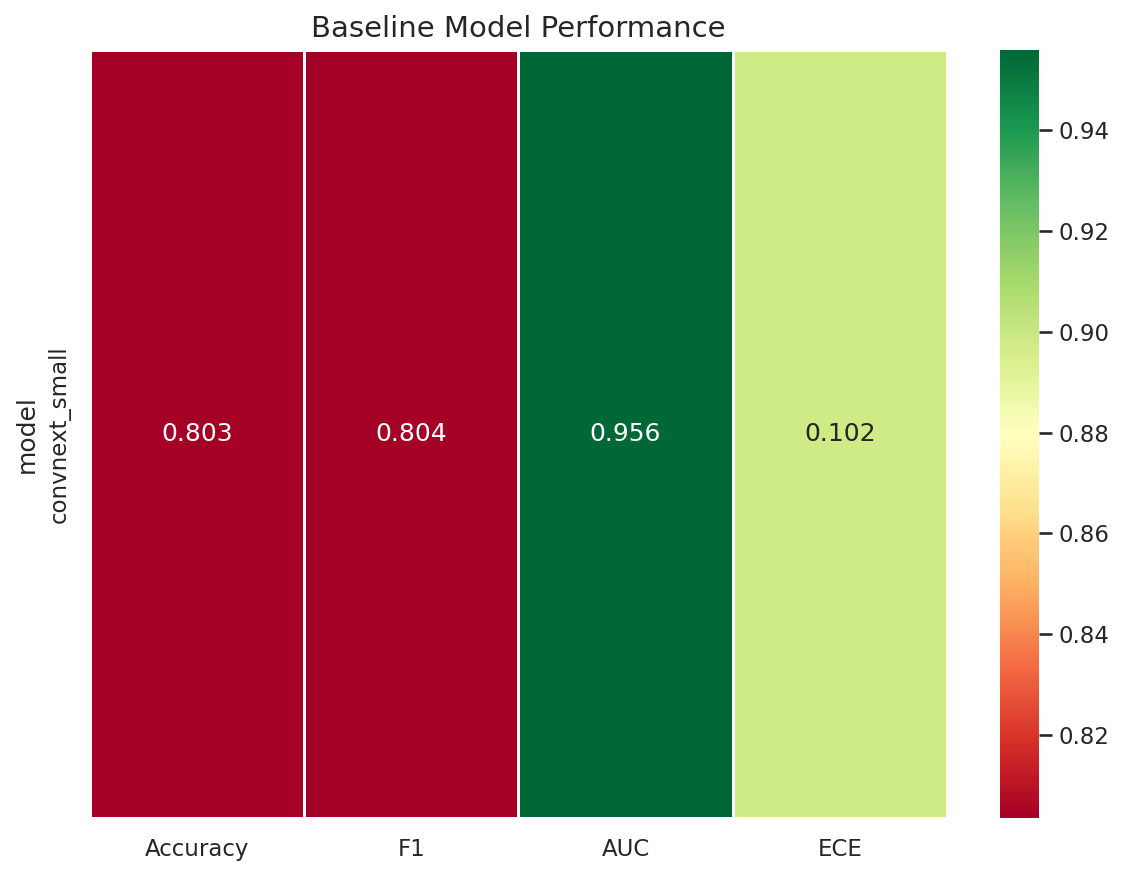

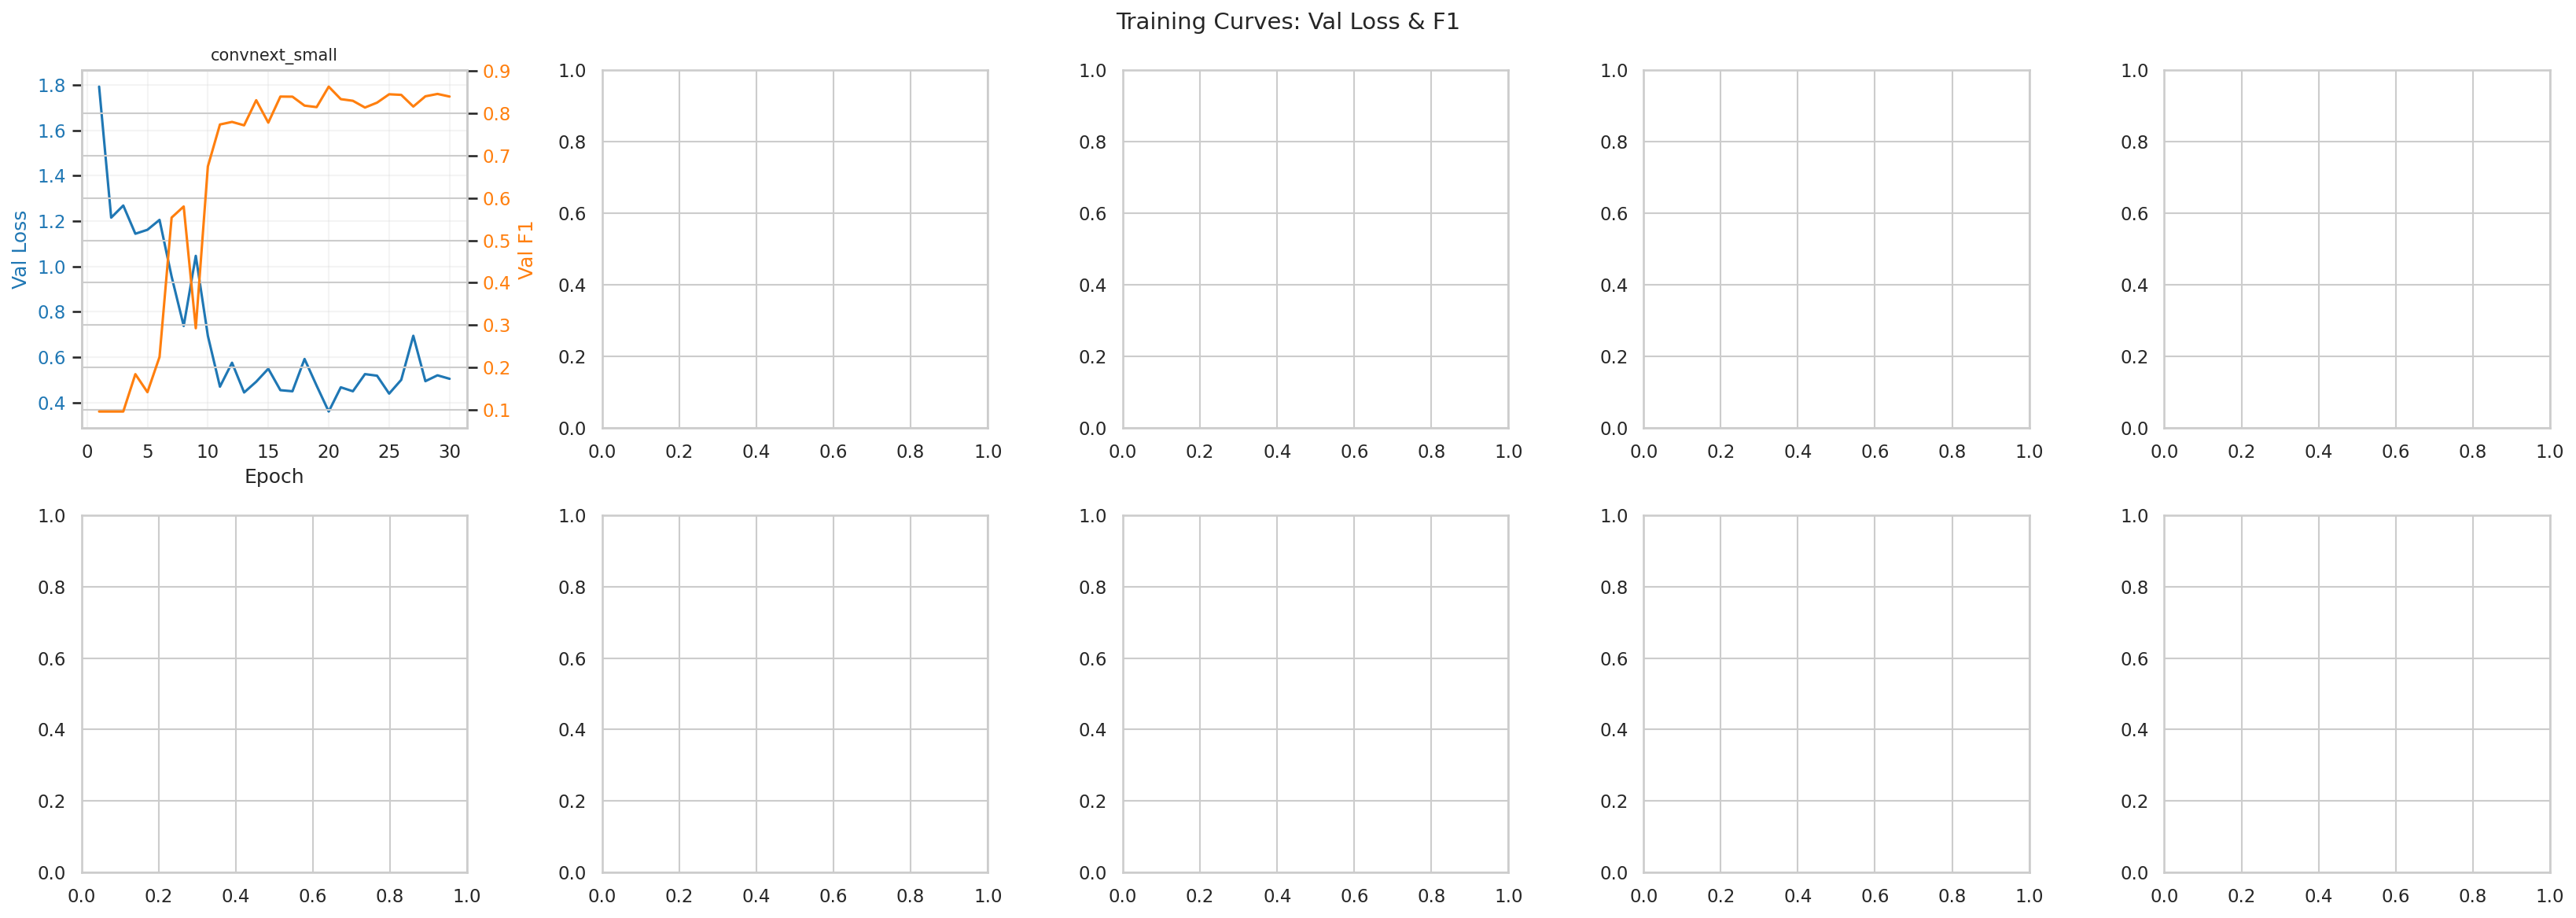

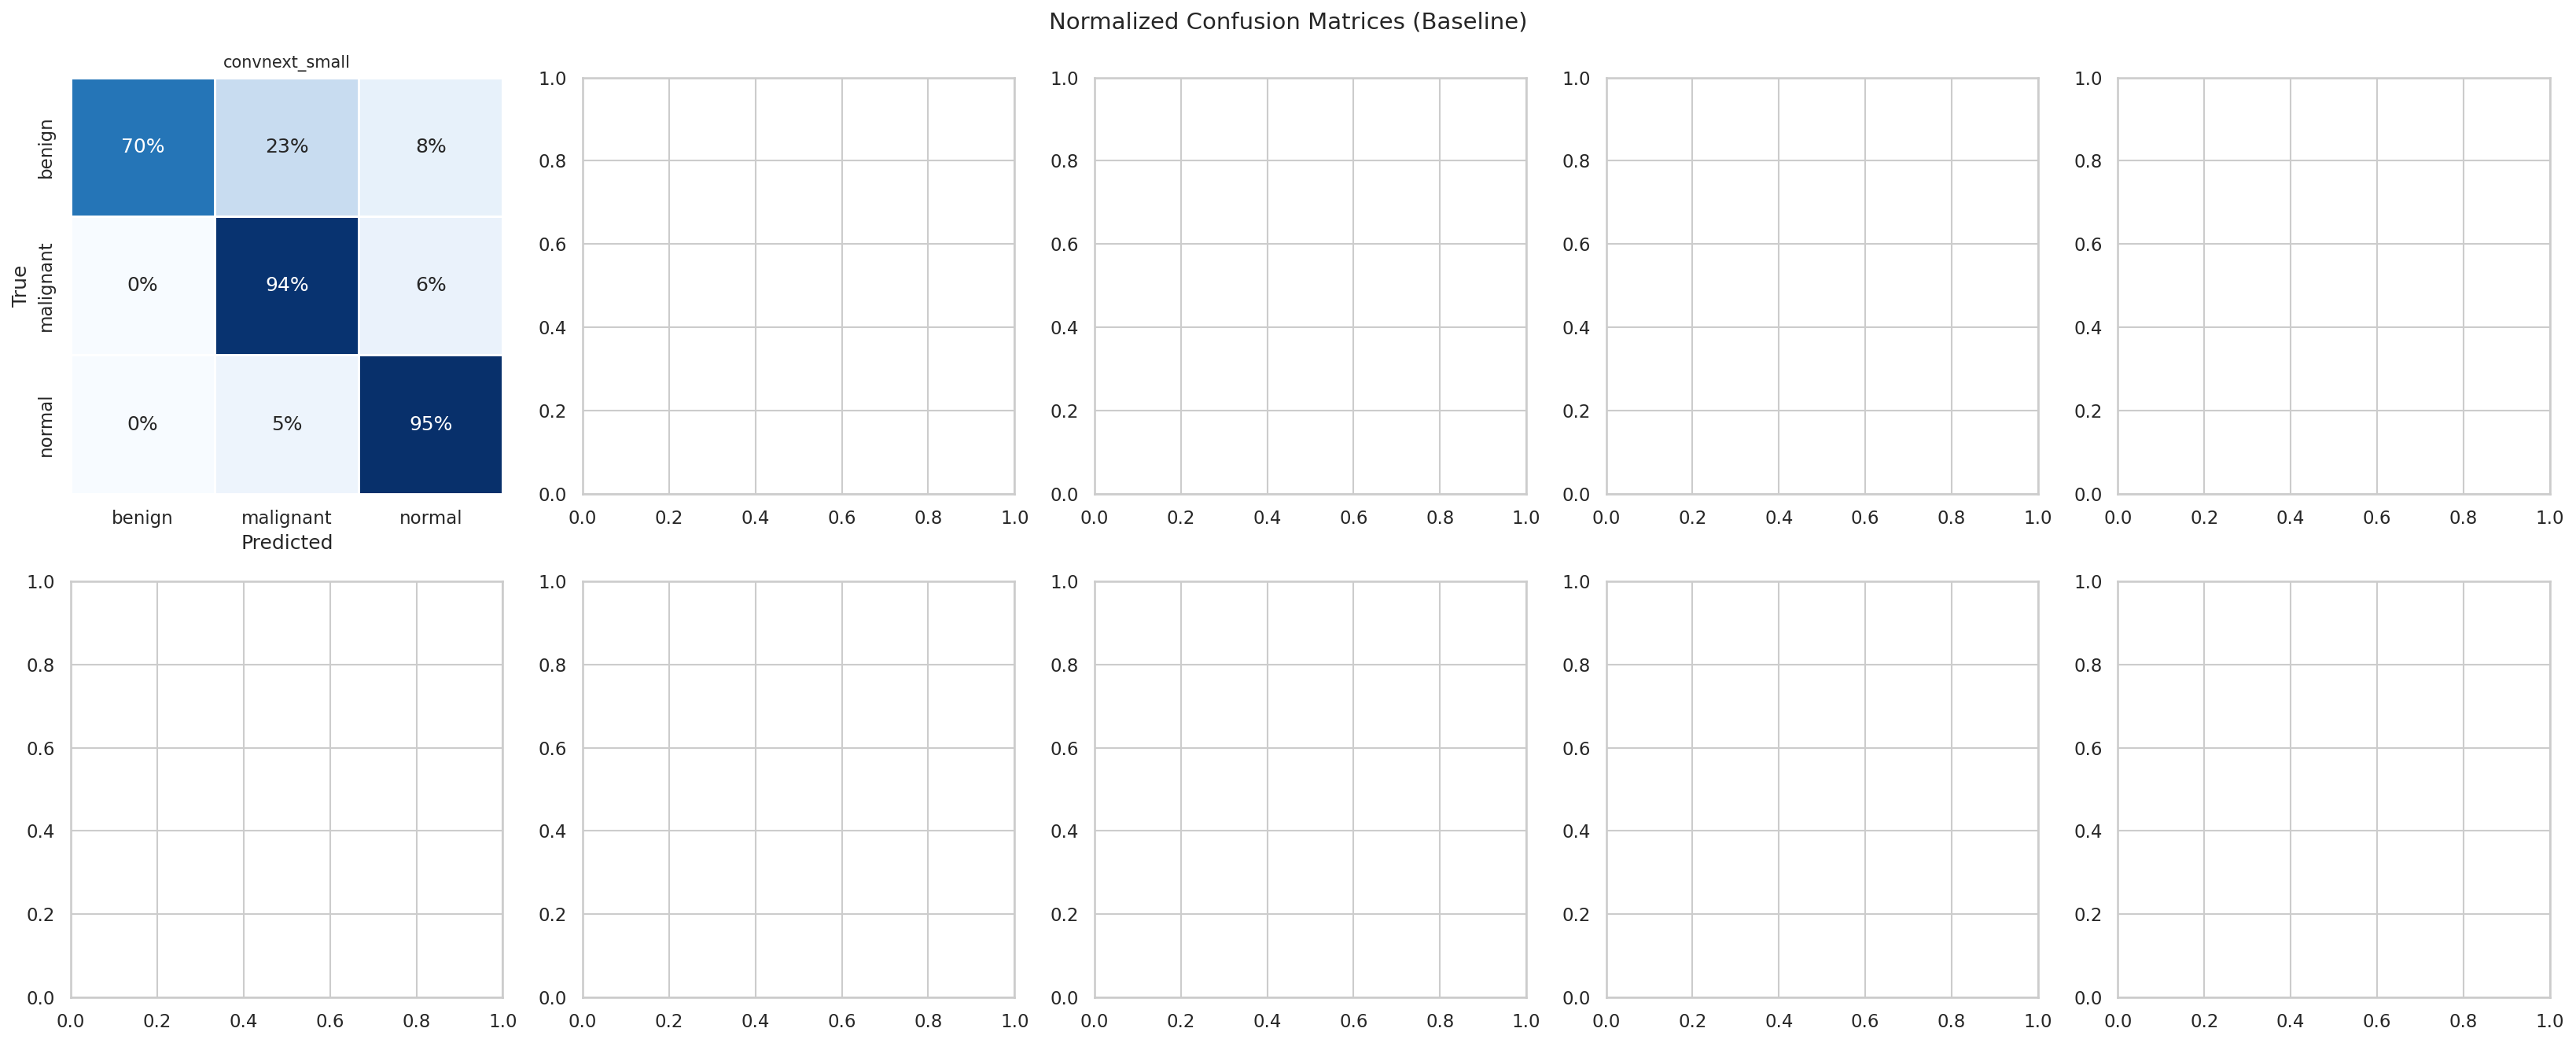

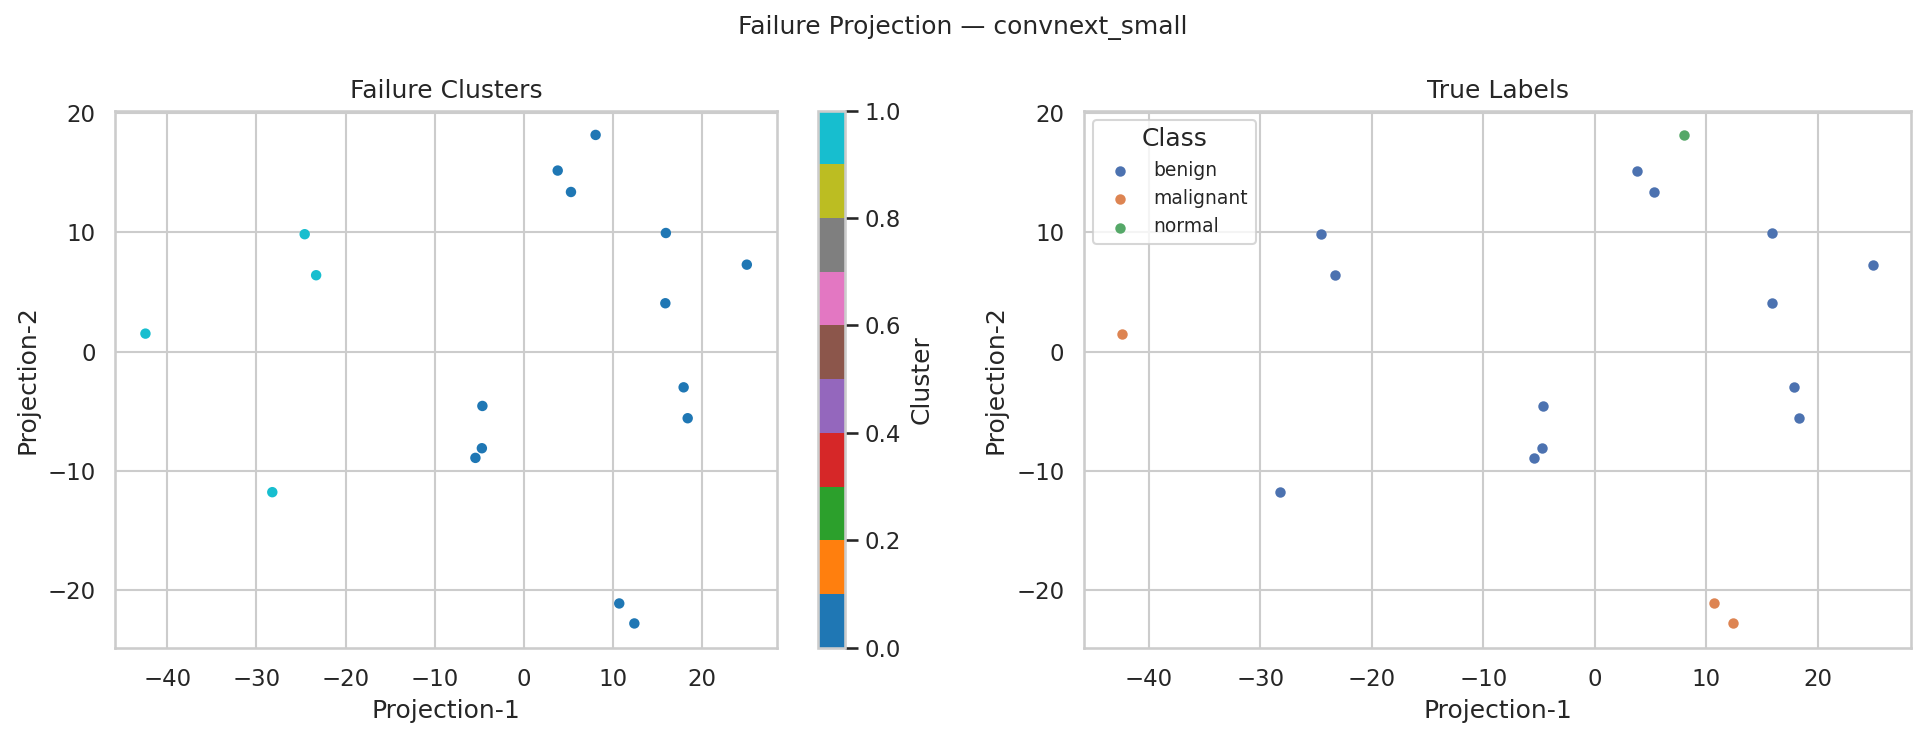

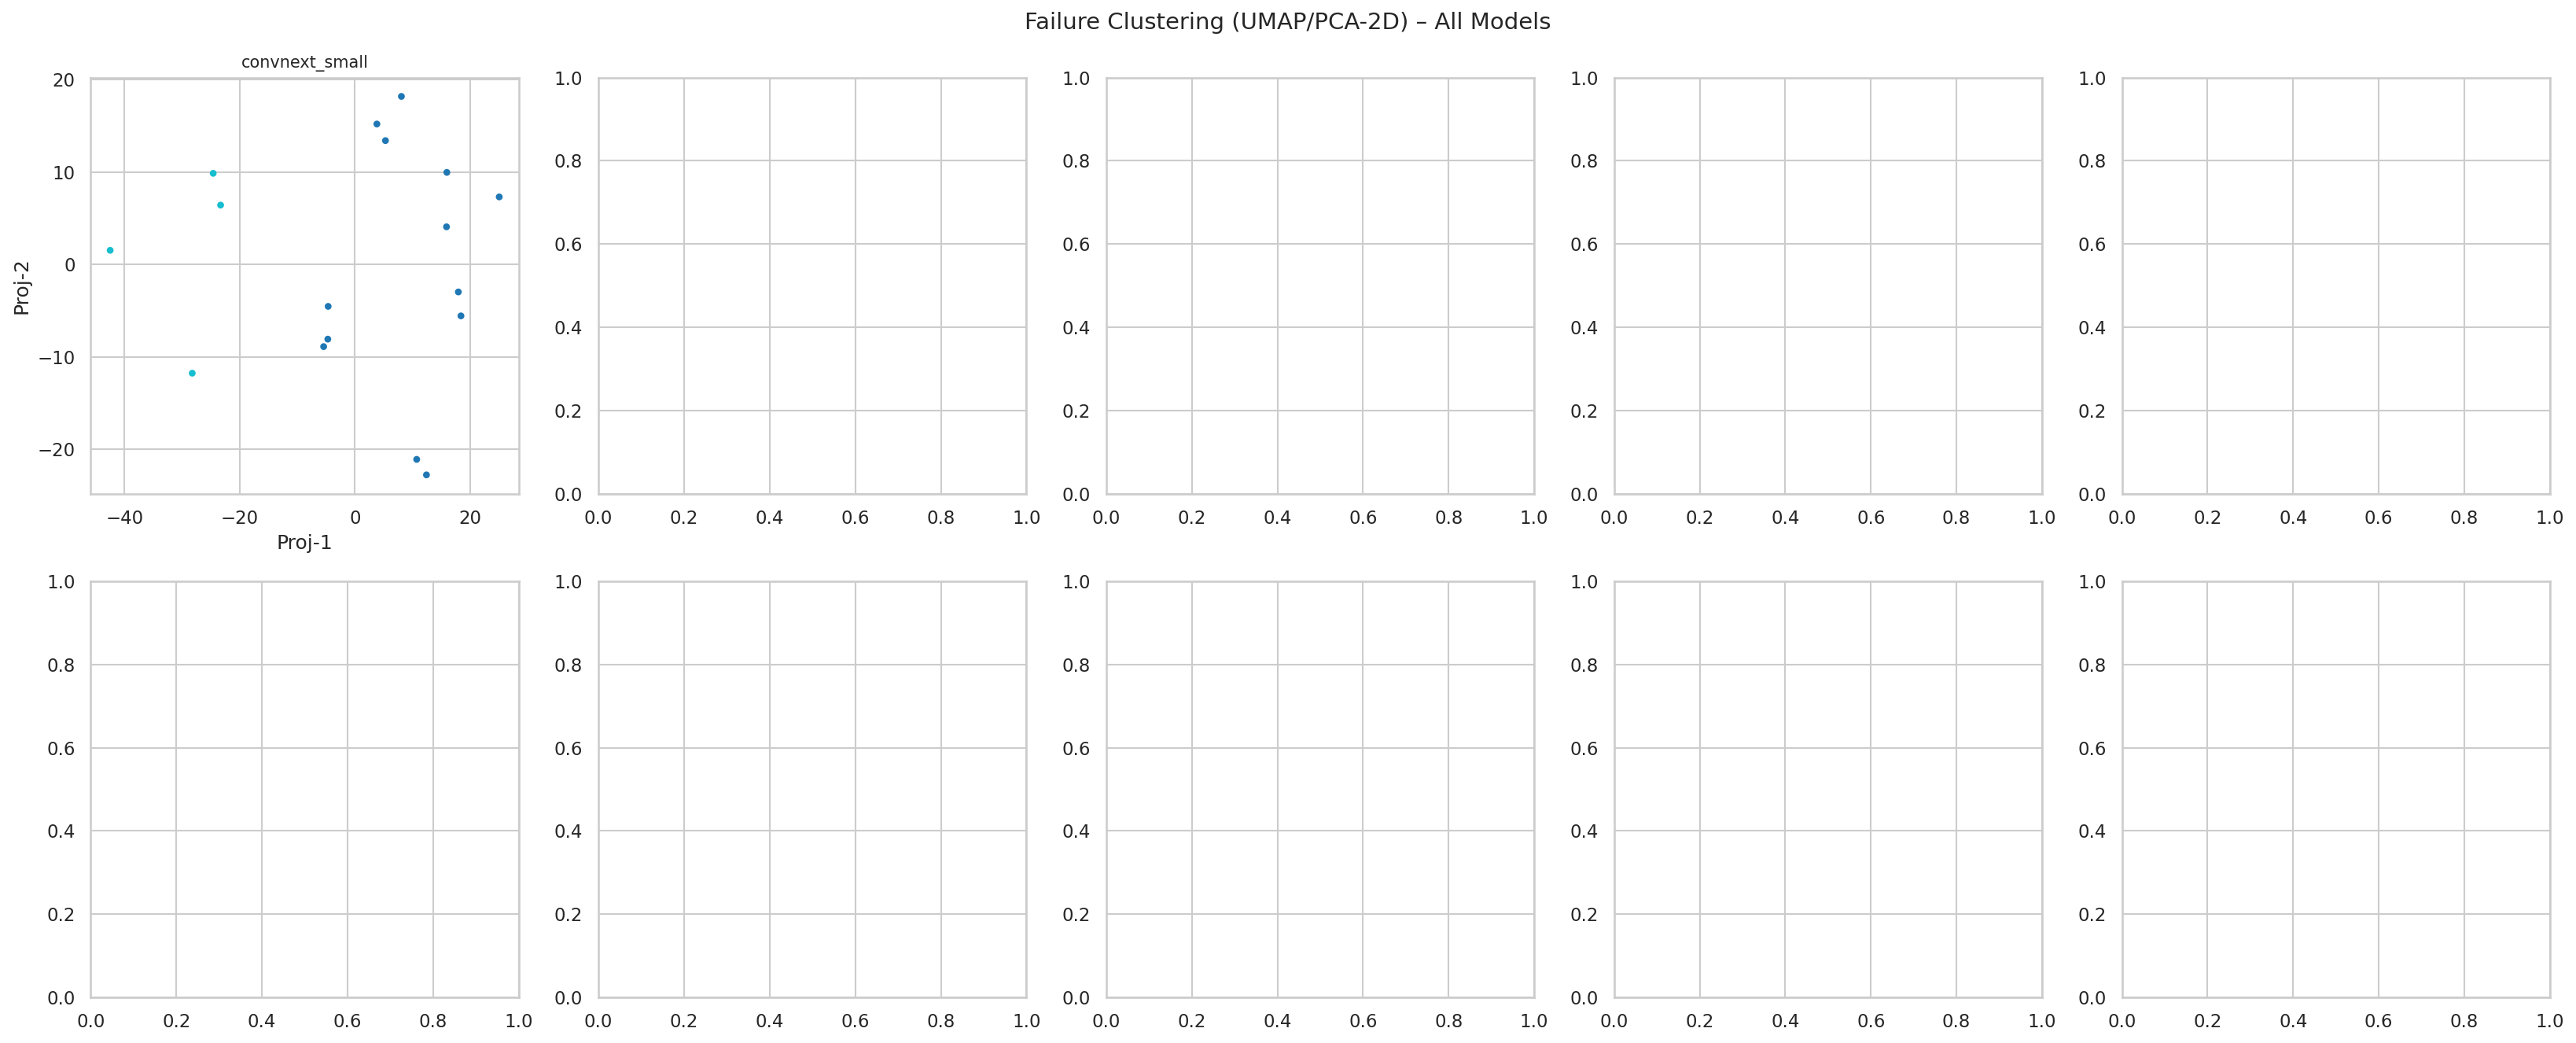

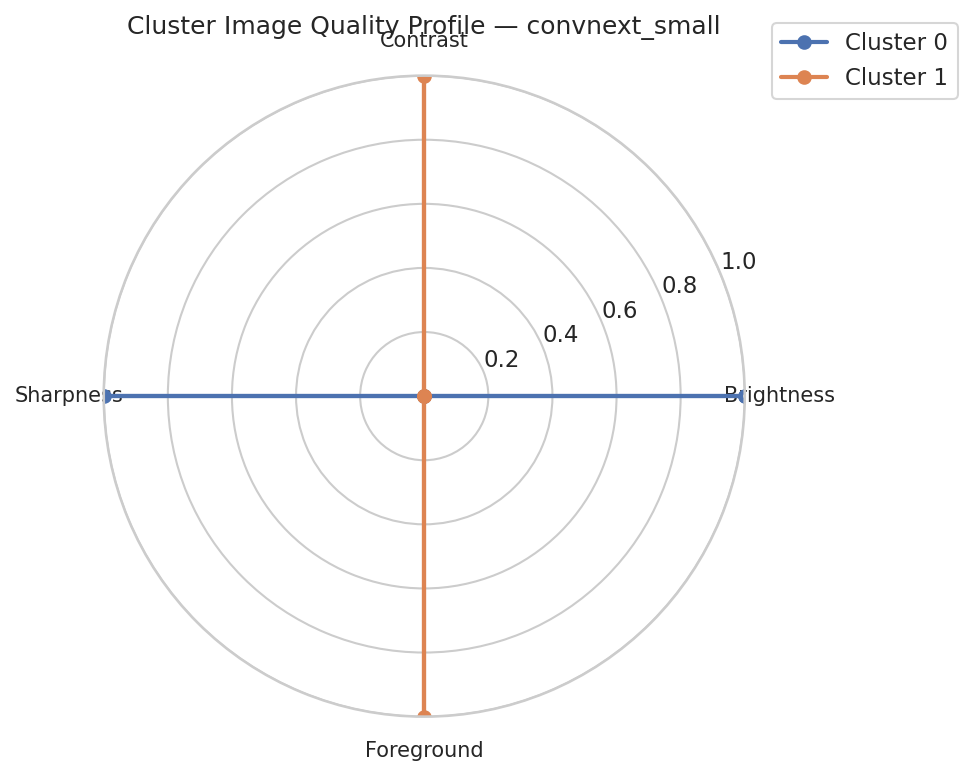

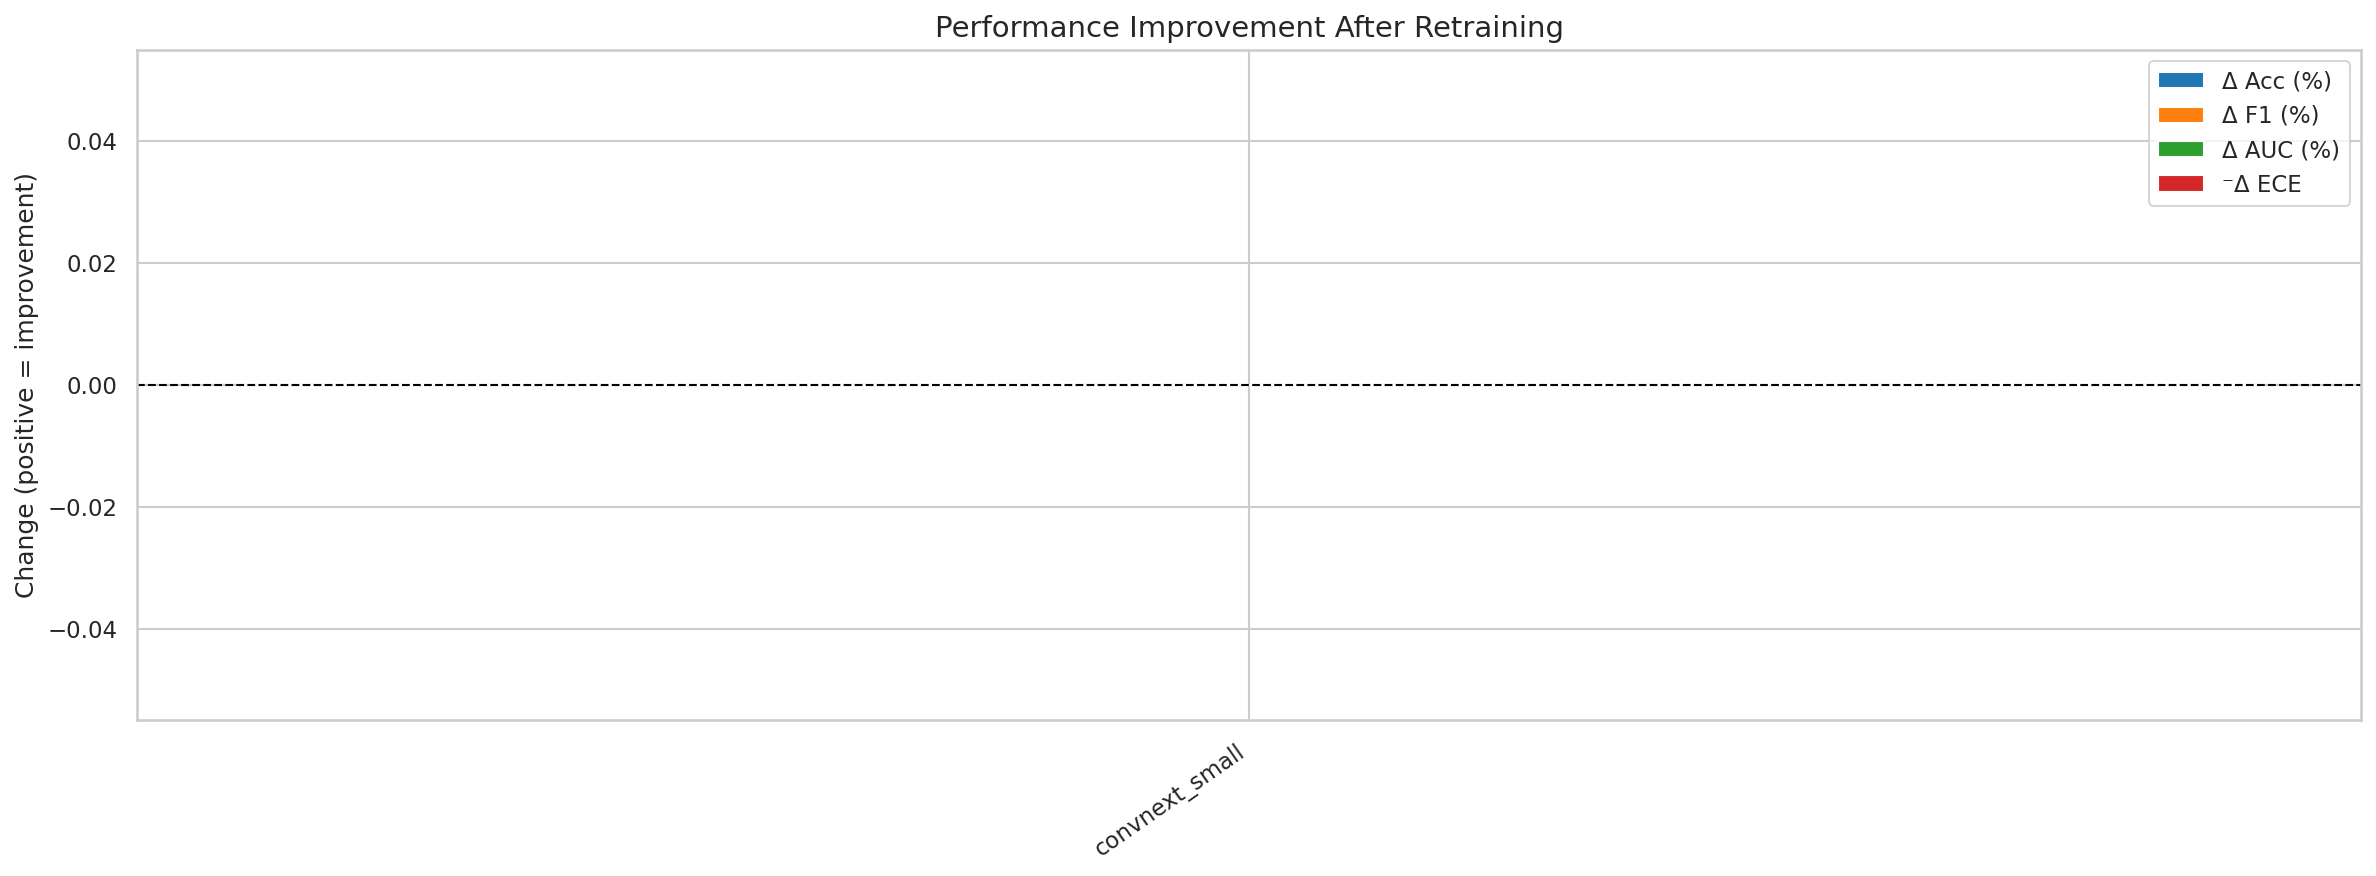

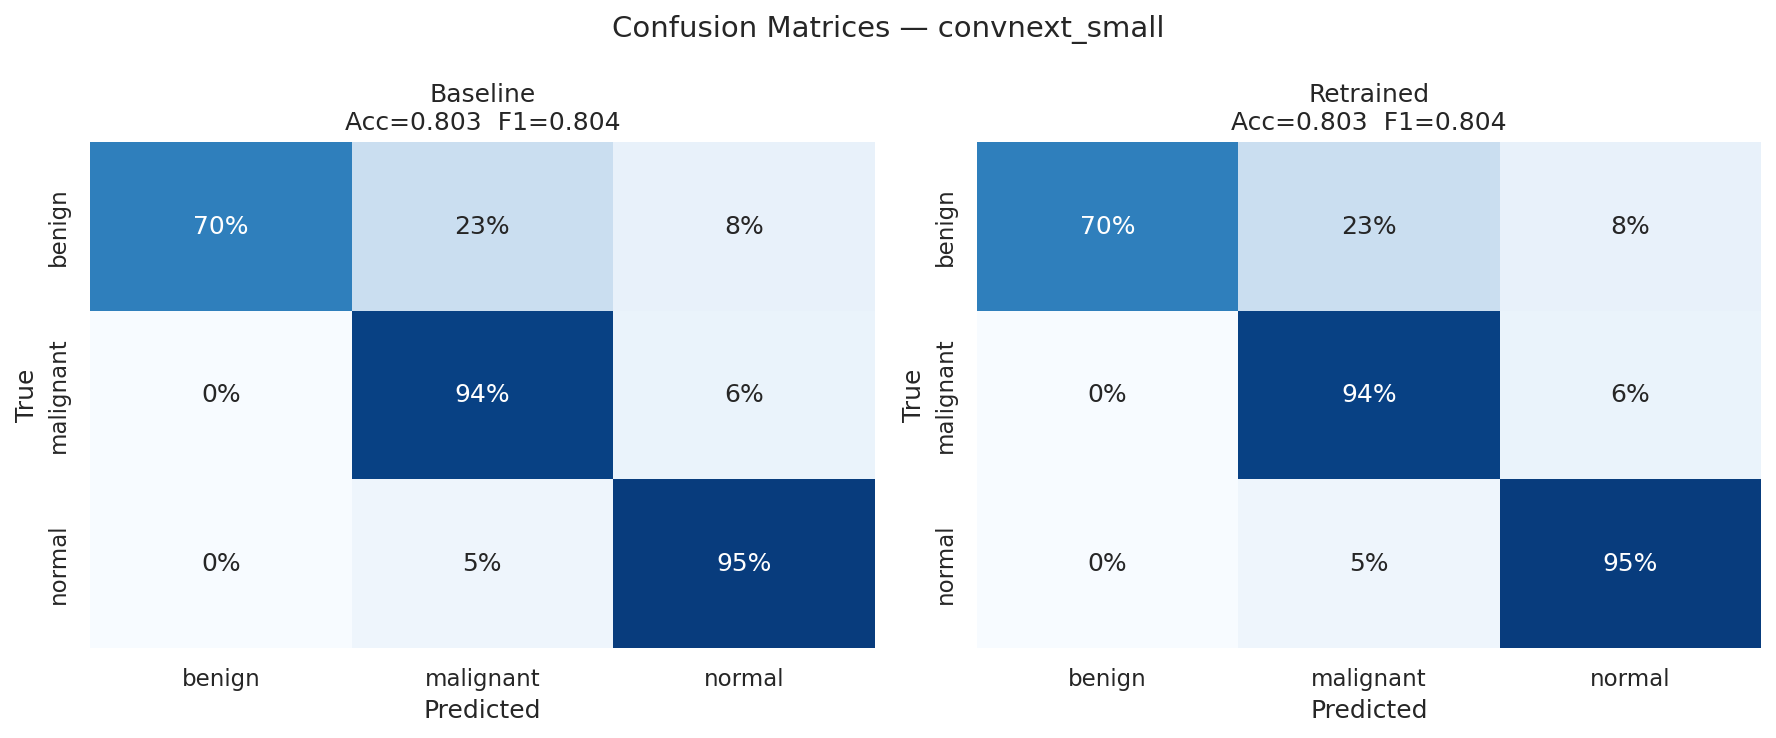

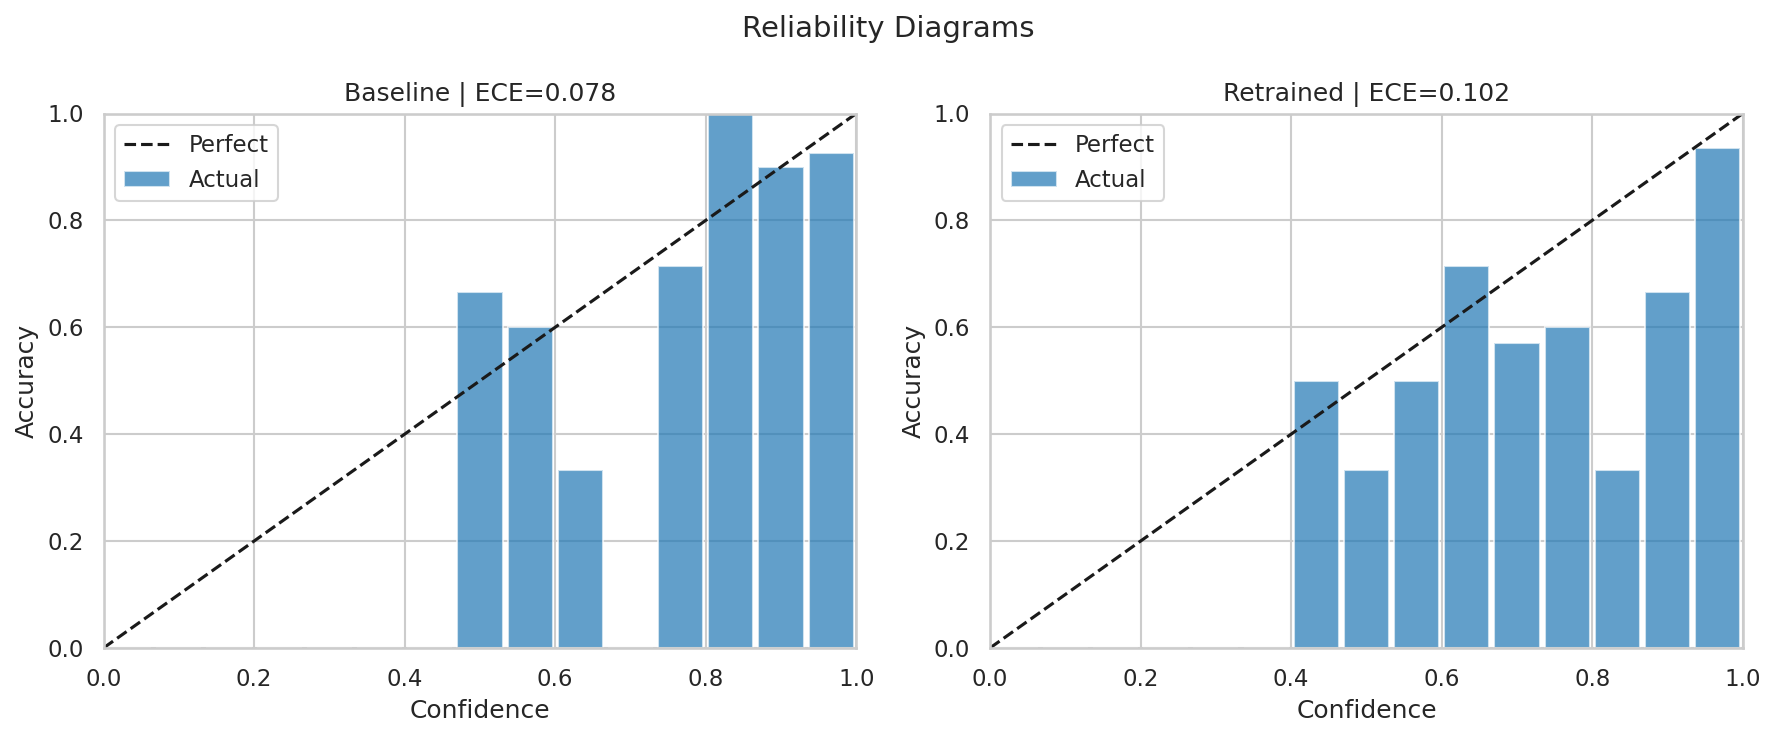

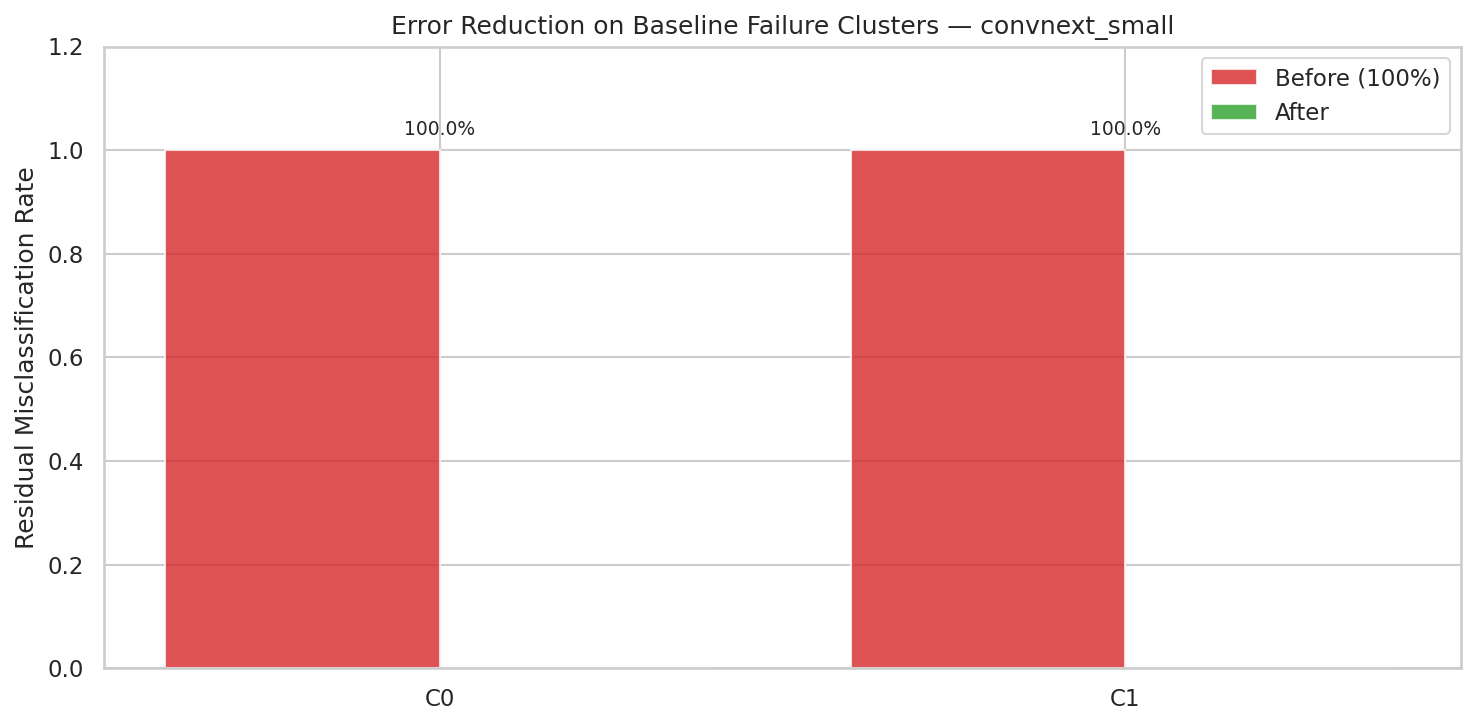


✅ Section 11 complete — All visualization tasks finished
    Figures saved to: /kaggle/working/figures


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure figures directory exists
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)


def reliability_bins(probs, labels, n_bins=15):
    """
    Compute bins for reliability diagram.
    Returns: center, accuracy, confidence, count per bin.
    """
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == labels).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    centers, bin_acc, bin_conf, counts = [], [], [], []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf > lo) & (conf <= hi)
        centers.append((lo + hi) / 2)
        counts.append(mask.sum())
        bin_acc.append(acc[mask].mean() if mask.any() else 0)
        bin_conf.append(conf[mask].mean() if mask.any() else 0)

    return np.array(centers), np.array(bin_acc), np.array(bin_conf), np.array(counts)


# ── Select best model for detailed figures ─────────────────────────────
if len(improvement_df) > 0:
    best_model = improvement_df.sort_values('retrained_f1', ascending=False).iloc[0]['model']
else:
    best_model = baseline_df.sort_values('test_f1', ascending=False).iloc[0]['model']

print(f"📊 Best model selected for detailed figures: {best_model}")


# ───────────────────────────────────────────────────────────────────────
# Figure 1 — Baseline Performance Heatmap
# ───────────────────────────────────────────────────────────────────────
fig1_df = baseline_df.set_index('model')[['test_accuracy', 'test_f1', 'test_auc', 'test_ece']].rename(
    columns={
        'test_accuracy': 'Accuracy',
        'test_f1': 'F1',
        'test_auc': 'AUC',
        'test_ece': 'ECE'
    }
)

# Invert ECE for green=good in heatmap
plot_df = fig1_df.copy()
plot_df['ECE'] = 1 - plot_df['ECE']  # Lower ECE → higher value → greener

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    plot_df,
    annot=fig1_df,  # Show original values
    fmt='.3f',
    cmap='RdYlGn',
    cbar=True,
    linewidths=0.5
)
plt.title("Baseline Model Performance", fontsize=14)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig1_baseline_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


# ───────────────────────────────────────────────────────────────────────
# Figure 2 — Training Curves (Val Loss & Val F1)
# ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 8), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    hist = all_histories.get(model_name, {})

    if len(hist.get('val_loss', [])) == 0:
        ax.axis('off')
        continue

    epochs = np.arange(1, len(hist['val_loss']) + 1)

    ax.plot(epochs, hist['val_loss'], color='tab:blue', label='Val Loss')
    ax.set_ylabel('Val Loss', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_xlabel('Epoch')
    ax.set_title(model_name, fontsize=10)
    ax.grid(True, alpha=0.2)

    ax2 = ax.twinx()
    ax2.plot(epochs, hist['val_f1'], color='tab:orange', label='Val F1')
    ax2.set_ylabel('Val F1', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.suptitle("Training Curves: Val Loss & F1", fontsize=14, y=0.97)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig2_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()


# ───────────────────────────────────────────────────────────────────────
# Figure 3 — Baseline Confusion Matrices
# ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in baseline_confusions:
        ax.axis('off')
        continue

    cm = baseline_confusions[model_name]
    cmn = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-10)  # Avoid division by zero

    sns.heatmap(
        cmn,
        annot=True,
        fmt='.0%',
        cmap='Blues',
        xticklabels=CONFIG['class_names'],
        yticklabels=CONFIG['class_names'],
        ax=ax,
        cbar=False,
        linewidths=0.5
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle("Normalized Confusion Matrices (Baseline)", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig3_confusion_baseline.png", dpi=300, bbox_inches='tight')
plt.show()


# ───────────────────────────────────────────────────────────────────────
# Figure 4 — Best Model: Cluster & Label Projection
# ───────────────────────────────────────────────────────────────────────
if best_model in all_clustered:
    best_clustered = all_clustered[best_model]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

    # Cluster view
    sc = axes[0].scatter(
        best_clustered['umap_x'],
        best_clustered['umap_y'],
        c=best_clustered['cluster'],
        cmap='tab10',
        s=16
    )
    axes[0].set_xlabel('Projection-1')
    axes[0].set_ylabel('Projection-2')
    axes[0].set_title('Failure Clusters')
    plt.colorbar(sc, ax=axes[0], label='Cluster')

    # True label view
    for label_id, name in enumerate(CONFIG['class_names']):
        sub = best_clustered[best_clustered['true_label'] == label_id]
        axes[1].scatter(sub['umap_x'], sub['umap_y'], s=16, label=name)

    axes[1].set_xlabel('Projection-1')
    axes[1].set_ylabel('Projection-2')
    axes[1].set_title('True Labels')
    axes[1].legend(title='Class', fontsize=9)

    plt.suptitle(f"Failure Projection — {best_model}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig4_projection_best_model.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print(f"⚠️ Skipping Figure 4: no clustered data for best model {best_model}")


# ───────────────────────────────────────────────────────────────────────
# Figure 5 — All Models: Cluster Projection
# ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in all_clustered:
        ax.axis('off')
        continue

    cdf = all_clustered[model_name]
    sc = ax.scatter(cdf['umap_x'], cdf['umap_y'], c=cdf['cluster'], cmap='tab10', s=10)
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Proj-1')
    ax.set_ylabel('Proj-2')

plt.suptitle("Failure Clustering (UMAP/PCA-2D) – All Models", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig5_projection_all_models.png", dpi=300, bbox_inches='tight')
plt.show()


# ───────────────────────────────────────────────────────────────────────
# Figure 6 — Cluster Image Quality Radar Chart
# ───────────────────────────────────────────────────────────────────────
if best_model in all_profiles and not all_profiles[best_model].empty:
    profile_df = all_profiles[best_model]

    feats = [
        'brightness_mean',
        'contrast_mean',
        'sharpness_mean',
        'foreground_size_mean'
    ]

    radar = profile_df[['cluster'] + feats].copy()

    # Normalize features across clusters
    for feat in feats:
        mn, mx = radar[feat].min(), radar[feat].max()
        if pd.isna(mn) or pd.isna(mx) or mx <= mn:
            radar[feat] = 0.5
        else:
            radar[feat] = (radar[feat] - mn) / (mx - mn)

    angles = np.linspace(0, 2 * np.pi, len(feats), endpoint=False).tolist()
    angles += angles[:1]  # Circle back

    fig = plt.figure(figsize=(7, 7), dpi=150)
    ax = fig.add_subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[feat] for feat in feats] + [row[feats[0]]]
        ax.plot(angles, values, marker='o', linewidth=2, label=f"Cluster {int(row['cluster'])}")
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Brightness', 'Contrast', 'Sharpness', 'Foreground'], fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster Image Quality Profile — {best_model}", fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig6_cluster_radar.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print(f"⚠️ Skipping Figure 6: no cluster profile for {best_model}")


# ───────────────────────────────────────────────────────────────────────
# Figure 7 — Improvement Bar Chart
# ───────────────────────────────────────────────────────────────────────
if len(improvement_df) > 0:
    x = np.arange(len(improvement_df))
    width = 0.2

    fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

    metrics = [
        ('delta_acc_pct', 'Δ Acc (%)'),
        ('delta_f1_pct', 'Δ F1 (%)'),
        ('delta_auc_pct', 'Δ AUC (%)'),
        ('delta_ece', 'Δ ECE')  # ECE: we plot actual delta (lower is better)
    ]

    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for i, (col, label) in enumerate(metrics):
        vals = improvement_df[col].values
        if col == 'delta_ece':
            vals = -vals  # Invert so that positive = improvement
            label = '⁻Δ ECE'  # Negative delta = better

        ax.bar(x + (i - 1.5) * width, vals, width, label=label, color=colors[i])

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(improvement_df['model'], rotation=35, ha='right')
    ax.set_ylabel('Change (positive = improvement)')
    ax.set_title("Performance Improvement After Retraining", fontsize=14)
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig7_improvement_bars.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 7: improvement_df is empty")


# ───────────────────────────────────────────────────────────────────────
# Figure 8 — Before/After Confusion Comparison
# ───────────────────────────────────────────────────────────────────────
if len(improvement_df) > 0 and best_model in retrained_confusions:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    base_row = baseline_df[baseline_df['model'] == best_model].iloc[0]
    ret_row = improvement_df[improvement_df['model'] == best_model].iloc[0]

    items = [
        (
            axes[0],
            baseline_confusions[best_model],
            f"Baseline\nAcc={base_row['test_accuracy']:.3f}  F1={base_row['test_f1']:.3f}"
        ),
        (
            axes[1],
            retrained_confusions[best_model],
            f"Retrained\nAcc={ret_row['retrained_acc']:.3f}  F1={ret_row['retrained_f1']:.3f}"
        )
    ]

    for ax, cm, title in items:
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
        sns.heatmap(
            cmn,
            annot=True,
            fmt='.0%',
            cmap='Blues',
            xticklabels=CONFIG['class_names'],
            yticklabels=CONFIG['class_names'],
            ax=ax,
            cbar=False,
            vmin=0, vmax=1
        )
        ax.set_title(title)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.suptitle(f"Confusion Matrices — {best_model}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig8_confusion_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 8: retrained confusion data unavailable")


# ───────────────────────────────────────────────────────────────────────
# Figure 9 — Reliability Diagrams (Baseline vs Retrained)
# ───────────────────────────────────────────────────────────────────────
if best_model in retrained_predictions:
    base_pred = all_predictions[best_model]
    base_probs = np.stack(base_pred['prob_vector'].apply(lambda x: np.fromstring(x, sep=',')))
    base_labels = base_pred['true_label'].values

    ret_probs = retrained_predictions[best_model]['probs']
    ret_labels = retrained_predictions[best_model]['labels']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    items = [
        (axes[0], base_probs, base_labels, f"Baseline | ECE={compute_ece(base_probs, base_labels):.3f}"),
        (axes[1], ret_probs, ret_labels, f"Retrained | ECE={compute_ece(ret_probs, ret_labels):.3f}")
    ]

    for ax, probs, labels, title in items:
        centers, bacc, bconf, _ = reliability_bins(probs, labels, CONFIG['ece_bins'])
        ax.bar(centers, bacc, width=1 / CONFIG['ece_bins'] * 0.9, alpha=0.7, color='tab:blue', label='Actual')
        ax.plot([0, 1], [0, 1], '--', color='k', label='Perfect')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.set_title(title)
        ax.legend()

    plt.suptitle("Reliability Diagrams", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig9_ece_reliability.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 9: no retrained predictions for best model")


# ───────────────────────────────────────────────────────────────────────
# Figure 10 — Residual Error Reduction by Cluster
# ───────────────────────────────────────────────────────────────────────
if best_model in all_clustered and best_model in retrained_predictions:
    clustered = all_clustered[best_model]

    ret_df = pd.DataFrame({
        'image_path': retrained_predictions[best_model]['paths'],
        'true_label': retrained_predictions[best_model]['labels'],
        'pred_label': retrained_predictions[best_model]['preds'],
    })

    cluster_map = clustered[['image_path', 'cluster']].drop_duplicates()
    ret_clustered = ret_df.merge(cluster_map, on='image_path', how='inner')

    clusters = sorted(clustered['cluster'].unique())
    before_rates = [1.0] * len(clusters)  # Baseline failure rate = always failing

    after_rates = []
    for c in clusters:
        sub = ret_clustered[ret_clustered['cluster'] == c]
        after_rates.append(
            float((sub['true_label'] != sub['pred_label']).mean()) if len(sub) > 0 else 0
        )

    x = np.arange(len(clusters))
    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

    ax.bar(x - 0.2, before_rates, 0.4, color='tab:red', label='Before (100%)', alpha=0.8)
    ax.bar(x + 0.2, after_rates, 0.4, color='tab:green', label='After', alpha=0.8)

    for i, (b, a) in enumerate(zip(before_rates, after_rates)):
        ax.text(i, max(b, a) + 0.03, f"{(b - a)*100:.1f}%", ha='center', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([f"C{c}" for c in clusters])
    ax.set_ylabel('Residual Misclassification Rate')
    ax.set_ylim(0, 1.2)
    ax.set_title(f"Error Reduction on Baseline Failure Clusters — {best_model}")
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig10_cluster_error_reduction.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 10: insufficient data for cluster error analysis")


print("\n✅ Section 11 complete — All visualization tasks finished")
print(f"    Figures saved to: {CONFIG['figures_dir']}")

In [16]:
from collections import Counter
from pathlib import Path

def pretty_model_name(name: str) -> str:
    """
    Convert internal model identifier to human-readable display name.
    Unified across datasets.
    """
    return {
        'resnet50': 'ResNet-50',
        'resnet101': 'ResNet-101',
        'densenet121': 'DenseNet-121',
        'efficientnet_b3': 'EfficientNet-B3',
        'efficientnet_b5': 'EfficientNet-B5',
        'mobilenetv3_large_100': 'MobileNetV3-Large',
        'vit_base_patch16_224': 'ViT-B/16',
        'swin_tiny_patch4_window7_224': 'Swin-Tiny',
        'convnext_small': 'ConvNeXt-Small',
        'maxvit_tiny_tf_224': 'MaxViT-Tiny'
    }.get(name, name)


# ─────────────────────────────────────────────────────────────────────
# Build Markdown Summary
# ─────────────────────────────────────────────────────────────────────
summary_lines = []

# ── Improvement Table (if retraining was run) ──────────────────────
if len(improvement_df) > 0:
    header = (
        "| Model | Family | Acc (base→ret) | F1 (base→ret) | "
        "AUC (base→ret) | ECE (base→ret) | Δ Acc % | Strategy |"
    )
    sep = "|---|---|---:|---:|---:|---:|---:|---|"

    summary_lines.extend([header, sep])

    for _, row in improvement_df.iterrows():
        summary_lines.append(
            f"| {pretty_model_name(row['model'])} | {row['family'].upper()} | "
            f"{row['baseline_acc']:.3f}→{row['retrained_acc']:.3f} | "
            f"{row['baseline_f1']:.3f}→{row['retrained_f1']:.3f} | "
            f"{row['baseline_auc']:.3f}→{row['retrained_auc']:.3f} | "
            f"{row['baseline_ece']:.3f}→{row['retrained_ece']:.3f} | "
            f"{row['delta_acc_pct']:+.1f}% | {row['strategy'].title()} |"
        )
else:
    summary_lines.append("📌 Retraining evaluation is unavailable — no `improvement_df` data.")
    summary_lines.append("Ensure `Section 10: Retraining` ran successfully.")


# ── Best Overall Baseline Model ───────────────────────────────────
best_baseline = None
if len(baseline_df) > 0:
    best_baseline = baseline_df.sort_values('test_f1', ascending=False).iloc[0]

final_best_baseline = (
    f"- Best performing baseline model: {pretty_model_name(best_baseline['model'])} "
    f"(F1={best_baseline['test_f1']:.3f}, "
    f"Acc={best_baseline['test_accuracy']:.3f}, "
    f"AUC={best_baseline['test_auc']:.3f}, "
    f"ECE={best_baseline['test_ece']:.3f})"
    if best_baseline is not None else
    "- Best performing baseline model: unavailable"
)


# ── Most Improved After Retraining ────────────────────────────────
most_improved = None
if len(improvement_df) > 0:
    most_improved = improvement_df.sort_values('delta_f1_pct', ascending=False).iloc[0]

final_most_improved = (
    f"- Most improved model: {pretty_model_name(most_improved['model'])} "
    f"(ΔF1={most_improved['delta_f1_pct']:+.1f}%, "
    f"final F1={most_improved['retrained_f1']:.3f})"
    if most_improved is not None else
    "- Most improved model: unavailable"
)


# ── Dominant Failure Pattern Across Models ────────────────────────
all_failure_pairs = []
for df in all_failures.values():
    if len(df) > 0:
        all_failure_pairs.extend(zip(df['true_label'], df['pred_label']))

if all_failure_pairs:
    dominant_true, dominant_pred = Counter(all_failure_pairs).most_common(1)[0][0]
    true_name = CONFIG['class_names'][dominant_true]
    pred_name = CONFIG['class_names'][dominant_pred]
    dominant_text = f"{true_name} → {pred_name}"
else:
    dominant_text = "No consistent misclassification pattern detected"


# ── Deployment Recommendation (BUSI-specific) ───────────────────
clinical_recommendation = (
    "Use the retrained best-performing model only as an assistant for breast ultrasound interpretation, "
    "not for autonomous diagnosis. Deploy with calibration monitoring, failure-cluster audits, "
    "radiologist review, and local site validation before clinical use. "
    "Pay special attention to differentiating benign masses from malignant ones, "
    "and monitor scan quality (brightness/contrast) as a potential confounder."
)


# ── Final Summary Text Assembly ─────────────────────────────────
final_text = (
    "\n".join(summary_lines) +
    "\n\n" +
    final_best_baseline + "\n" +
    final_most_improved + "\n" +
    f"- Dataset: Breast Ultrasound (BUSI) – 3-class, stratified-split experiment\n" +
    f"- Dataset-level dominant misclassification pattern: {dominant_text}\n" +
    f"- Recommendation for clinical deployment: {clinical_recommendation}\n\n" +
    "This summary synthesizes model performance, retraining improvements, "
    "and failure patterns across all models. For visualization details, "
    "see figures/ and results/. Always validate new models on local hospital data before use."
)

# ── Save to Results Directory ────────────────────────────────────
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
summary_path = Path(CONFIG['results_dir']) / 'FINAL_SUMMARY_BUSI.md'
summary_path.write_text(final_text)

# ── Output ─────────────────────────────────────────────────────
print("\n📘 FINAL REPORT — Breast Ultrasound (BUSI)")
print("━" * 80)
print(final_text.strip())
print(f"✅ Saved to: {summary_path}")
print("✓ Section 12 complete")


📘 FINAL REPORT — Breast Ultrasound (BUSI)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
| Model | Family | Acc (base→ret) | F1 (base→ret) | AUC (base→ret) | ECE (base→ret) | Δ Acc % | Strategy |
|---|---|---:|---:|---:|---:|---:|---|
| ConvNeXt-Small | TRANSFORMER | 0.803→0.803 | 0.804→0.804 | 0.956→0.956 | 0.102→0.102 | +0.0% | Both |

- Best performing baseline model: ConvNeXt-Small (F1=0.804, Acc=0.803, AUC=0.956, ECE=0.102)
- Most improved model: ConvNeXt-Small (ΔF1=+0.0%, final F1=0.804)
- Dataset: Breast Ultrasound (BUSI) – 3-class, stratified-split experiment
- Dataset-level dominant misclassification pattern: benign → malignant
- Recommendation for clinical deployment: Use the retrained best-performing model only as an assistant for breast ultrasound interpretation, not for autonomous diagnosis. Deploy with calibration monitoring, failure-cluster audits, radiologist review, and local site validation before clinical use. Pay special attention 

In [17]:
# FINAL: Save cross-notebook compatible results
DATASET_NAME = 'busi'
DATASET_DISPLAY = 'Breast Ultrasound (BUSI)'

print(f"Saving cross-notebook results for {DATASET_DISPLAY}...")

# Ensure output directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

# ── 1. Improvement Results (retrained vs baseline) ──────────────────
if 'improvement_df' in globals() and isinstance(improvement_df, pd.DataFrame):
    improvement_df_export = improvement_df.copy()
    improvement_df_export['dataset'] = DATASET_NAME
    out_path = f'{CONFIG["results_dir"]}/improvement_{DATASET_NAME}.csv'
    improvement_df_export.to_csv(out_path, index=False)
    print(f"  ✅ Saved improvement results: {len(improvement_df_export)} models → {out_path}")
else:
    print("  ⚠️  improvement_df not found or empty — skipping improvement export")

# ── 2. Untargeted Control Results (compute-matched baseline) ──────────
if 'untargeted_df' in globals() and isinstance(untargeted_df, pd.DataFrame):
    untargeted_df_export = untargeted_df.copy()
    untargeted_df_export['dataset'] = DATASET_NAME
    out_path = f'{CONFIG["results_dir"]}/untargeted_control_{DATASET_NAME}.csv'
    untargeted_df_export.to_csv(out_path, index=False)
    print(f"  ✅ Saved untargeted control: {len(untargeted_df_export)} models → {out_path}")
else:
    print("  ⚠️  untargeted_df not found or empty — skipping untargeted control export")

# ── 3. Cluster Summary (failure clustering metadata) ────────────────
cluster_rows = []
has_cluster_data = False

if 'cluster_summaries' in globals() and isinstance(cluster_summaries, dict):
    for model_name, summary in cluster_summaries.items():
        # Count total failures for this model
        n_failures = len(all_failures[model_name]) if model_name in all_failures else 0

        cluster_rows.append({
            'model': model_name,
            'dataset': DATASET_NAME,
            'best_k': summary.get('best_k', 2),
            'best_k_bic': summary.get('best_k_bic', 2),
            'silhouette': summary.get('silhouette', float('nan')),
            'mean_ari': summary.get('mean_ari', float('nan')),
            'n_failures': n_failures,
        })
    has_cluster_data = len(cluster_rows) > 0

if has_cluster_data:
    cluster_summary_df = pd.DataFrame(cluster_rows)
    out_path = f'{CONFIG["results_dir"]}/cluster_summary_{DATASET_NAME}.csv'
    cluster_summary_df.to_csv(out_path, index=False)
    print(f"  ✅ Saved cluster summaries: {len(cluster_summary_df)} rows → {out_path}")
else:
    print("  ⚠️  No clustering summaries available — skipping cluster export")

# ── 4. Temperature Scaling Results (calibration) ─────────────────────
if 'baseline_df' in globals() and isinstance(baseline_df, pd.DataFrame):
    temp_cols = ['model', 'temperature', 'test_ece', 'test_ece_temp_scaled']
    if all(c in baseline_df.columns for c in temp_cols):
        temp_export = baseline_df[temp_cols].copy()
        temp_export['dataset'] = DATASET_NAME
        out_path = f'{CONFIG["results_dir"]}/temperature_scaling_{DATASET_NAME}.csv'
        temp_export.to_csv(out_path, index=False)
        print(f"  ✅ Saved temperature scaling: {len(temp_export)} rows → {out_path}")
    else:
        missing_cols = [c for c in temp_cols if c not in baseline_df.columns]
        print(f"  ⚠️  Missing temp scaling columns: {missing_cols} — skipping export")
else:
    print("  ⚠️  baseline_df not available — skipping temperature scaling export")

# ── Final Summary ──────────────────────────────────────────────────
print(f"\n✅ All cross-notebook result files saved for dataset='{DATASET_NAME}'")
print(f"   These can now be combined with 'covid' results for unified analysis.")
print(f"   Next step: Use `Section 13: Cross-Dataset Comparison` for merging and insights.")

Saving cross-notebook results for Breast Ultrasound (BUSI)...
  ✅ Saved improvement results: 1 models → /kaggle/working/results/improvement_busi.csv
  ✅ Saved untargeted control: 1 models → /kaggle/working/results/untargeted_control_busi.csv
  ✅ Saved cluster summaries: 1 rows → /kaggle/working/results/cluster_summary_busi.csv
  ✅ Saved temperature scaling: 1 rows → /kaggle/working/results/temperature_scaling_busi.csv

✅ All cross-notebook result files saved for dataset='busi'
   These can now be combined with 'covid' results for unified analysis.
   Next step: Use `Section 13: Cross-Dataset Comparison` for merging and insights.
